#1. Import Dataset

In [1]:
import tensorflow as tf


In [2]:
from google.colab import drive
import numpy as np
import pandas as pd


drive.mount('/content/drive/', force_remount=True)

dir = '/content/drive/My Drive/TA/'
import sys
sys.path.insert(0, dir)


import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings
from CombinedDecays import CombinedDecays
import datetime


Mounted at /content/drive/


In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      print(f"Found GPU: {gpu.name}")
  except RuntimeError as e:
    print(e)
else:
  print("No GPU devices found.")

Found GPU: /physical_device:GPU:0


In [ ]:
df = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/NO2_Land_Grid_Jabodetabek.csv")
wind = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/Wind_NO2_MeanDaily_Jabodetabek.csv")


In [ ]:
# no2_df = pd.read_csv("/content/drive/MyDrive/TA/Dataset/no2.csv")
# wind_df=  pd.read_csv("/content/drive/MyDrive/TA/Dataset/wind.csv")
# no2_sea = pd.read_csv("/content/drive/MyDrive/TA/Dataset/Sea/NO2_Sea_wind.csv")

#2. Class Definition

In [4]:
import tensorflow as tf
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings

DTYPE='float32'

class MultiSigmaFourierFeatures(tf.keras.layers.Layer):
    def __init__(self, sigmas, mapping_size, trainable_B=False, **kwargs):
        super().__init__(**kwargs)
        self.sigmas = sigmas
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.fourier_layers = [
            FourierFeatureMapping(
                mapping_size=self.mapping_size,
                sigma=sigma,
                trainable_B=self.trainable_B
            ) for sigma in self.sigmas
        ]

    def call(self, inputs):
        outputs = [layer(inputs) for layer in self.fourier_layers]
        return tf.concat(outputs, axis=-1)



class FourierFeatureMapping(tf.keras.layers.Layer):
    def __init__(self, mapping_size=256, sigma=1.0, trainable_B=False, **kwargs):
        super(FourierFeatureMapping, self).__init__(**kwargs)
        self.mapping_size = mapping_size
        self.sigma = sigma
        self.trainable_B = trainable_B

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # Use RandomNormal initializer with stddev = sigma
        self.B = self.add_weight(
            name="B_matrix",
            shape=(input_dim, self.mapping_size),
            initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=self.sigma),
            trainable=self.trainable_B
        )

    def call(self, inputs):
        proj = tf.matmul(inputs, self.B)
        return tf.concat([tf.sin(proj), tf.cos(proj)], axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "mapping_size": self.mapping_size,
            "sigma": self.sigma,
            "trainable_B": self.trainable_B
        })
        return config

# Define model architecture for 2D spatial domain with time
class PINN_NeuralNet(tf.keras.Model):
    def __init__(self, lb, ub,
                 output_dim=1,
                 num_hidden_layers=8,
                 num_neurons_per_layer=20,
                 activation='tanh',
                 mapping_size=256,
                 sigma=1.0,
                 sigmas=[1.0, 3.0],
                 kernel_initializer='glorot_normal',
                 trainable_B=True,
                 **kwargs):
        super().__init__(**kwargs)
        self.lb = lb
        self.ub = ub
        self.num_hidden_layers = num_hidden_layers
        self.output_dim = output_dim
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.sigmas = sigmas
        self.scale = tf.keras.layers.Lambda(lambda x: 2.0*(x - lb)/(ub - lb) - 1.0)
        self.fourier_features = MultiSigmaFourierFeatures(sigmas=self.sigmas, mapping_size=self.mapping_size, trainable_B=True)
        # self.fourier_features = FourierFeatureMapping(mapping_size=mapping_size, sigma=sigma, trainable_B=trainable_B)

        # dummy_input = tf.keras.Input(shape=(3,))
        # _ = self.fourier_features(dummy_input)

        self.hidden = [tf.keras.layers.Dense(num_neurons_per_layer,
                                             activation=tf.keras.activations.get(activation),
                                             kernel_initializer=kernel_initializer)
                       for _ in range(self.num_hidden_layers)]
        self.out = tf.keras.layers.Dense(output_dim)


    def call(self, X):
        """Forward-pass through neural network."""
        X = tf.convert_to_tensor(X, dtype=tf.float32)  # Ensure X is a Tensor
        X = tf.reshape(X, (-1, 3))  # Ensure input is 2D (batch_size, features) for [t, x, y]
        Z = self.scale(X)
        Z = self.fourier_features(Z)
        for i in range(self.num_hidden_layers):
            Z = self.hidden[i](Z)
        return self.out(Z)


class PINN_PDESolver():
    def __init__(self, model, X_r, fun_r, get_r,lambd=1):
        self.model = model

        # Store collocation points
        # X_r = tf.convert_to_tensor(X_r, dtype=tf.float32)  # Ensure X_r is a Tensor
        self.t = X_r[:,0:1]
        self.x = X_r[:,1:2]
        self.y = X_r[:,2:3]
        self.lambd = lambd
        # Initialize history of losses and global iteration counter
        self.hist = []
        self.lambd_list = []  # Initialize lambda list here
        self.iter = 0
        self.fun_r = fun_r
        self.get_r_fn = get_r

    def get_r(self, t, x, y, u_data, Wu=None, Wv=None): # Added default None for Wu, Wv
        return self.get_r_fn(t=t, x=x, y=y, model=self.model, lambd = self.lambd, fun_r=self.fun_r, u_data=u_data, Wu=Wu, Wv=Wv)


    def loss_fn(self, X, u, Wu, Wv):
        # X = tf.convert_to_tensor(X, dtype=tf.float32)
        # X = tf.reshape(X, (-1, 3))  # Ensure input is 3D [t, x, y]
        # u = tf.convert_to_tensor(u, dtype=tf.float32)

        # Compute phi_r
        t = X[:, 0:1]
        x = X[:, 1:2]
        y = X[:, 2:3]
        r = self.get_r(t, x, y, u, Wu, Wv)
        phi_r = r

        # Initialize loss
        loss = phi_r

        return loss, phi_r
    @tf.function
    def get_grad(self, X, u, Wu, Wv):
        X = tf.cast(X, tf.float32)
        u = tf.cast(u, tf.float32)
        Wu = tf.cast(Wu, tf.float32)
        Wv = tf.cast(Wv, tf.float32)


        with tf.GradientTape() as tape:
            loss, phi_r = self.loss_fn(X, u, Wu, Wv)
        grad_theta = tape.gradient(loss, self.model.trainable_variables)

        return loss, grad_theta

    def solve_with_TFoptimizer(self, optimizer, X, u, W_u, W_v, inverse=True, N=None, min_loss=None, timeout=None, batch_size=None):
        """
        Modified training loop that keeps the loss_callback function and reports loss per iteration.
        """
        X = tf.convert_to_tensor(X, dtype=tf.float32)
        u = tf.convert_to_tensor(u, dtype=tf.float32)
        W_u = tf.convert_to_tensor(W_u, dtype=tf.float32)
        W_v = tf.convert_to_tensor(W_v, dtype=tf.float32)


        data = tf.data.Dataset.from_tensor_slices((X, u, W_u, W_v))

        if batch_size is not None:
            data = data.shuffle(buffer_size=len(X)).batch(batch_size).map(
                lambda x, u_batch, wu, wv: (tf.cast(x, tf.float32), tf.cast(u_batch, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))
            ).prefetch(tf.data.AUTOTUNE)
        else:
            data = data.batch(len(X)).map(
                lambda x, u_batch, wu, wv: (tf.cast(x, tf.float32), tf.cast(u_batch, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))
            ).prefetch(tf.data.AUTOTUNE)


        # The loss_callback now accepts the results of a step as arguments.
        def loss_callback(loss, phi_r, epoch_num):
            self.current_loss = loss.numpy()
            self.phi_r = phi_r.numpy()

            # Print every 50 iterations to avoid excessive output
            if self.iter % 50 == 0:
                print(f"Epoch {epoch_num}, Iteration {self.iter}, Loss: {self.current_loss:.6e}, Phi_r: {self.phi_r:.6e}")

            self.hist.append(self.current_loss)
            self.iter += 1

        start_time = time.time()
        epochs = N if N is not None else 1000 # Set a default number of epochs if N isn't specified

        # Explicit loops for epochs and iterations (batches)
        for epoch in range(epochs):
            if timeout is not None and (time.time() - start_time > timeout):
                print("Timeout reached. Stopping training.")
                break

            total_epoch_loss = 0
            num_batches = 0
            for batch_X, batch_u, batch_Wu, batch_Wv in data:
                # Execute one training step (one batch)
                loss, grads = self.get_grad(batch_X, batch_u, batch_Wu, batch_Wv)
                optimizer.apply_gradients(zip(grads, self.model.trainable_variables))

                # Accumulate loss for the epoch
                total_epoch_loss += loss.numpy()
                num_batches += 1

                # Recalculate phi_r for reporting (optional, can be removed for speed)
                # phi_r = self.loss_fn(batch_X, batch_u, batch_Wu, batch_Wv)[1]
                # loss_callback(loss, phi_r, epoch + 1) # Callback per batch (noisy)

            # Calculate average epoch loss and call callback once per epoch
            avg_epoch_loss = total_epoch_loss / num_batches if num_batches > 0 else 0
            # We don't have phi_r readily available as it's calculated per batch,
            # so we'll just report the average epoch loss.
            self.current_loss = avg_epoch_loss
            self.hist.append(self.current_loss)
            self.iter += 1 # Increment iteration counter once per epoch

            # Print every epoch
            print(f"--- End of Epoch {epoch+1}, Iteration {self.iter}, Average Epoch Loss: {self.current_loss:.6e} ---")


            if min_loss is not None and self.current_loss < min_loss:
                print(f"Minimum loss of {min_loss} reached. Stopping training.")
                break


    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print('It {:05d}: l_u = {:10.8e} loss = {:10.8e}'.format(self.iter,self.phi_0_b,self.current_loss))
        self.hist.append(self.current_loss)
        self.iter+=1

    def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
        upred = self.model(tf.cast(test_data, DTYPE))  # shape: [N, 1]

        # Reshape into [Nt+1, Nx+1, Ny+1]
        Nt, Nx, Ny = len(t_unique) - 1, len(x_unique) - 1, len(y_unique) - 1
        U = upred.numpy().reshape(Nt+1, Nx+1, Ny+1)

        # Create meshgrid for visualization
        T, X, Y = np.meshgrid(t_unique, x_unique, y_unique, indexing='ij')
        self.T_pred, self.X_pred, self.Y_pred = T, X, Y

        return U

    def plot_solution_at_time(self, U=None, time_idx=0, **kwargs):
        # If upred has not been predicted
        if U is None:
            U = self.predict_solution()

        # Plot solution at specific time
        fig = plt.figure(figsize=(9,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(self.X_pred[time_idx], self.Y_pred[time_idx], U[time_idx], cmap='viridis', **kwargs)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$y$')
        ax.set_zlabel('$u_\\theta(t,x,y)$')
        ax.set_title(f'Solution at t = {self.T_pred[time_idx,0,0]:.2f}')
        return ax

    def plot_loss_history(self, ax=None):
        if not ax:
            fig = plt.figure(figsize=(7,5))
            ax = fig.add_subplot(111)
        ax.semilogy(range(len(self.hist)), self.hist,'k-')
        ax.set_xlabel('$n_{epoch}$')
        ax.set_ylabel('$\\phi^{n_{epoch}}$')
        return ax



def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
    upred = self(tf.cast(test_data, DTYPE))  # shape: [N, 1]

    #     # Reshape into [Nt+1, Nx+1, Ny+1]
    # Nt, Nx, Ny = len(t_unique) - 1, len(x_unique) - 1, len(y_unique) - 1
    # U = upred.numpy().reshape(Nt+1, Nx+1, Ny+1)

    #     # Create meshgrid for visualization
    # T, X, Y = np.meshgrid(t_unique, x_unique, y_unique, indexing='ij')
    # self.T_pred, self.X_pred, self.Y_pred = T, X, Y

    return upred

def calculate_mae(u_pred, u_true):
    """Calculate Mean Absolute Error"""
    return np.mean(np.abs(u_true - u_pred))

def calculate_mape(u_pred, u_true, epsilon=1e-10):
    """Calculate Mean Absolute Percentage Error"""
    return 100 * np.mean(np.abs((u_true - u_pred) / (np.abs(u_true) + epsilon)))

def evaluate_solution(u_pred, u_true):
    """Evaluate solution using MAE and MAPE"""
    mae = calculate_mae(u_pred, u_true)
    mape = calculate_mape(u_pred, u_true)
    # r2 =   calculate_rel_l2(u_pred, u_true)

    return mae, mape

def calculate_rel_l2(u_pred, u_true, epsilon=1e-10):
    """Relative L2 norm error"""
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + epsilon)


def evaluate_param(lambda_pred, lambda_true):
    """Evaluate parameter using absolute error and percentage error"""
    abs_error = np.abs(lambda_true - lambda_pred)
    perc_error = 100 * abs_error / np.abs(lambda_true)
    return abs_error, perc_error

def plot_solution_slice(U, T, X, Y, time_idx=0):
    """Plot solution slice at specific time index"""
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X[time_idx], Y[time_idx], U[time_idx],
                          cmap='viridis', edgecolor='none')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u(t,x,y)')
    ax.set_title(f'Solution at t = {T[time_idx,0,0]:.2f}')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()


class Hybrid_IdentificationNet(PINN_NeuralNet):
    def __init__(self, initial_lambda, beta=1e-4, *args, **kwargs):
        # Call init of base class
        super().__init__(*args,**kwargs)
        self.initial_lambda = initial_lambda

        if isinstance(initial_lambda, (list, np.ndarray)):
            self.initial_lambda = np.array(initial_lambda, dtype=DTYPE)
        else:
            self.initial_lambda = initial_lambda

        # Initialize variable for lambda
        self.lambd = tf.Variable(initial_value=self.initial_lambda, trainable=True, dtype=DTYPE, constraint=lambda x: tf.clip_by_value(x, 1e-5, 10.0))
        self.lambd_list = []
        # self.beta = beta

        # # -- Parameters for the Gaussian Source Term --
        # # Strength of the source (needs to be positive)
        # self.source_A = tf.Variable(1.0, trainable=True, dtype=DTYPE,
        #                             constraint=lambda x: tf.nn.softplus(x)) # Ensures A > 0

        # # Center of the source
        # self.source_x0 = tf.Variable(0.0, trainable=True, dtype=DTYPE)
        # self.source_y0 = tf.Variable(0.0, trainable=True, dtype=DTYPE)

        # # Spread of the source (needs to be positive)
        # self.source_sigma_x = tf.Variable(1.0, trainable=True, dtype=DTYPE,
        #                                   constraint=lambda x: tf.nn.softplus(x)) # Ensures sigma > 0
        # # self.source_sigma_y = tf.Variable(1.0, trainable=True, dtype=DTYPE,
        # #                                   constraint=lambda x: tf.nn.softplus(x)) # Ensures sigma > 0

    def build(self, input_shape):
           super().build(input_shape)  # Ensure layers are initialized
           self.built = True


    def add_param(self):
        try:
          len(self.initial_lambda)
          self.initial_lambda = np.array(self.initial_lambda, dtype=DTYPE)
        except TypeError as e:
          pass

    @property
    def trainable_variables(self):
        # Combine neural network weights with lambda parameter
        return super().trainable_variables + [self.lambd]

class Hybrid_IdentificationSolver(PINN_PDESolver):
    def solve_with_TFoptimizer(self, optim_fwd, optim_param, get_r_param, X, u, W_u, W_v,
                               N_fwd=None, min_loss_fwd=None, timeout_fwd=None,
                               N_param=None, min_loss_param=None, timeout_param=None, modified=False, batch_size=None, **kwargs):
        self.changed = False
        self.lambd_list = []

        # Forward pass optimization
        super().solve_with_TFoptimizer(optim_fwd, X, u, W_u, W_v, N=N_fwd, min_loss=min_loss_fwd, timeout=timeout_fwd, batch_size=batch_size)

        # Add parameters after fitting with given data.
        self.model.add_param()
        self.changed = True

        print('\n\nFinding PDE parameters.')

        # Parameter optimization
        data = tf.data.Dataset.from_tensor_slices((X, u, W_u, W_v))
        if batch_size is not None:
            data = data.shuffle(buffer_size=len(X)).batch(batch_size).map(lambda x, u, wu, wv: (tf.cast(x, tf.float32), tf.cast(u, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))).prefetch(tf.data.AUTOTUNE)
        else:
            data = data.batch(len(X)).map(lambda x, u, wu, wv: (tf.cast(x, tf.float32), tf.cast(u, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))).prefetch(tf.data.AUTOTUNE) # Process all data as a single batch

        @tf.function
        def train_step_param():
            total_loss = 0.0
            num_batches = 0
            for batch_X, batch_u, batch_Wu, batch_Wv in data:
                batch_t = batch_X[:, 0:1]
                batch_x = batch_X[:, 1:2]
                batch_y = batch_X[:, 2:3]
                loss, grad_theta = get_r_param(batch_t, batch_x, batch_y, batch_Wu, batch_Wv, self.model)
                optim_param.apply_gradients(zip([grad_theta], [self.model.lambd]))
                total_loss += loss
                num_batches += 1
            return total_loss / tf.cast(num_batches, tf.float32)

        def loss_callback():
            loss = train_step_param()
            self.current_loss = loss.numpy()
            callback()

        def callback():
                lambd = self.model.lambd.numpy()
                self.model.lambd_list.append(lambd)

                if self.iter % 1 == 0:
                    print('It {:05d}: loss = {:10.8e} lambda = '.format(self.iter, self.current_loss) + str(lambd))

                self.hist.append(self.current_loss)
                self.iter += 1

        start_time = time.time()
        if N_param is not None:
            for _ in range(N_param):
                loss_callback()
            print ('{} iterations reached.'.format(N_param))
        elif min_loss_param is not None:
            while True:
                loss_callback()
                if self.current_loss < min_loss_param:
                    print ('Loss is reached. Current loss: {:10.8e}'.format(self.current_loss))
                    break
        elif timeout_param is not None:
            stop_after = time.time() + timeout_param
            while True:
                loss_callback()
                if time.time() > stop_after:
                    print ('Timeout is reached. Time elapsed: {} seconds'.format(time.time()-start_time))
                    break

    def loss_fn(self, X, u, Wu, Wv):
        # Initialize loss
        loss = 0
        phi_r = 0

        # phi_r is calculated only after
        # variables are added.
        if self.changed is not False:
            # Compute phi_r
            t = X[:, 0:1]
            x = X[:, 1:2]
            y = X[:, 2:3]
            # This part needs to be adjusted to get the corresponding W_u and W_v for the batch
            # For now, leaving it as is will likely cause an error here too if W_u and W_v are not batched.
            # A more robust solution would involve passing the wind data to loss_fn as well.
            r = self.get_r(t, x, y, u, Wu=Wu, Wv=Wv) # Pass Wu and Wv here
            phi_r =r
            # regularization_loss = self.beta / self.model.lambd
            loss += phi_r

        else:
            u_pred = self.model(X)
            loss += tf.reduce_mean(tf.square(u - u_pred))

        return loss, phi_r

    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print('It {:05d}: l_u = {:10.8e} loss = {:10.8e}'.format(self.iter,self.phi_0_b,self.current_loss))
            # print('It {:05d}: loss = {:10.8e}'.format(self.iter,self.current_loss))
        self.hist.append(self.current_loss)
        self.iter+=1

# Pra-pemrosesan Data

In [ ]:
df.columns

Index(['date', 'mean', 'longitude', 'latitude'], dtype='object')

In [ ]:
wind.dropna(inplace=True)
df.dropna(inplace = True)

In [ ]:
wind

,date,longitude,latitude,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed_10m,wind_direction_10m
1,2023-05-01,106.344359,-6.076563,0.104355,-0.164398,0.194722,122.406268
2,2023-05-01,106.343339,-6.067594,0.104355,-0.164398,0.194722,122.406268
4,2023-05-01,106.352747,-6.103510,0.104355,-0.164398,0.194722,122.406268
6,2023-05-01,106.351178,-6.078393,0.104355,-0.164398,0.194722,122.406268
7,2023-05-01,106.351430,-6.066554,0.104355,-0.164398,0.194722,122.406268
...,...,...,...,...,...,...,...
4370501,2025-04-29,107.286789,-6.201915,-1.248562,-0.054484,1.249751,2.498655
4370502,2025-04-29,107.286543,-6.190163,-1.248562,-0.054484,1.249751,2.498655
4370503,2025-04-29,107.284628,-6.178768,-1.248562,-0.054484,1.249751,2.498655
4370504,2025-04-29,107.286299,-6.151964,-1.248562,-0.054484,1.249751,2.498655


In [ ]:
df

,date,mean,longitude,latitude
1,2023-05-01,0.000106,106.344359,-6.076563
2,2023-05-01,0.000106,106.343339,-6.067594
4,2023-05-01,0.000106,106.352747,-6.103510
6,2023-05-01,0.000106,106.351178,-6.078393
7,2023-05-01,0.000106,106.351430,-6.066554
...,...,...,...,...
4370501,2025-04-29,0.000074,107.286789,-6.201915
4370502,2025-04-29,0.000048,107.286543,-6.190163
4370503,2025-04-29,0.000048,107.284628,-6.178768
4370504,2025-04-29,0.000048,107.286299,-6.151964


In [ ]:
df['date'] = pd.to_datetime(df['date'])
start_date = datetime.datetime(2023, 5, 1)
df = df[(df['date'] >= start_date)]
df=df.rename(columns={"longitude":"x_coord","latitude":"y_coord"})
wind=wind.rename(columns={"longitude":"x_coord","latitude":"y_coord"})

df.sort_values(by=['date','x_coord','y_coord'], inplace=True)

In [ ]:
df.describe()

,date,mean,x_coord,y_coord
count,3772707,3.772707e+06,3.772707e+06,3.772707e+06
mean,2024-04-27 02:54:13.631727616,1.063187e-04,1.068112e+02,-6.374735e+00
min,2023-05-01 00:00:00,-5.768733e-06,1.063433e+02,-6.782236e+00
25%,2023-10-21 00:00:00,7.209045e-05,1.066028e+02,-6.547693e+00
50%,2024-04-30 00:00:00,9.499345e-05,1.068151e+02,-6.362443e+00
75%,2024-10-24 00:00:00,1.280171e-04,1.070195e+02,-6.201893e+00
max,2025-04-29 00:00:00,7.509617e-04,1.072922e+02,-5.919887e+00
std,NaN,4.942891e-05,2.413386e-01,2.041004e-01


In [ ]:
wind.describe()

,x_coord,y_coord,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed_10m,wind_direction_10m
count,4.104060e+06,4.104060e+06,4.104060e+06,4.104060e+06,4.104060e+06,4.104060e+06
mean,1.068003e+02,-6.387460e+00,1.550578e-01,-2.516054e-02,8.673574e-01,1.696244e+02
std,2.397153e-01,1.974011e-01,1.031140e+00,4.994378e-01,7.651161e-01,1.097321e+02
min,1.063433e+02,-6.782236e+00,-5.212917e+00,-3.824649e+00,1.509067e-03,7.843643e-05
25%,1.065949e+02,-6.560043e+00,-3.700720e-01,-3.052228e-01,3.161758e-01,6.504277e+01
50%,1.067915e+02,-6.374793e+00,-3.249423e-02,-2.176348e-02,6.132222e-01,1.744876e+02
75%,1.069959e+02,-6.214243e+00,5.121918e-01,2.358580e-01,1.182850e+00,2.514486e+02
max,1.072922e+02,-5.941738e+00,6.126617e+00,2.163122e+00,6.444995e+00,3.599992e+02


## Pembersihan Data Polusi

In [ ]:
# no2_df = no2_df[no2_df.NO2_mean>=0]
df=df.rename(columns={"mean":"NO2_mean"})

df = df[df["NO2_mean"]>=0]

wind['date'] = pd.to_datetime(wind['date'])

merged_df = pd.merge(df, wind, on=['x_coord', 'y_coord', 'date'], how='inner')

display(merged_df.head())

,date,NO2_mean,x_coord,y_coord,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed_10m,wind_direction_10m
0,2023-05-01,0.000106,106.343339,-6.067594,0.104355,-0.164398,0.194722,122.406268
1,2023-05-01,0.000106,106.344359,-6.076563,0.104355,-0.164398,0.194722,122.406268
2,2023-05-01,0.000106,106.351178,-6.078393,0.104355,-0.164398,0.194722,122.406268
3,2023-05-01,0.000106,106.351430,-6.066554,0.104355,-0.164398,0.194722,122.406268
4,2023-05-01,0.000106,106.352747,-6.103510,0.104355,-0.164398,0.194722,122.406268


## Rata-rata Kecepatan Angin

In [ ]:
merged_df= merged_df.rename(columns = {"u_component_of_wind_10m":'u10',"v_component_of_wind_10m":'v10'})
merged_df = merged_df[["date","NO2_mean","u10","v10","x_coord","y_coord"]]

merged_df['u10']  = merged_df.groupby(['x_coord','y_coord'])['u10'].transform('mean')
merged_df['v10']  = merged_df.groupby(['x_coord','y_coord'])['v10'].transform('mean')

In [ ]:
merged_df.describe()

,date,NO2_mean,u10,v10,x_coord,y_coord
count,3659371,3.659371e+06,3.659371e+06,3.659371e+06,3.659371e+06,3.659371e+06
mean,2024-04-27 03:11:48.569315584,1.073432e-04,1.301236e-01,-3.079197e-02,1.068047e+02,-6.385380e+00
min,2023-05-01 00:00:00,1.179439e-06,-1.601214e-01,-2.703086e-01,1.063433e+02,-6.782236e+00
25%,2023-10-21 00:00:00,7.303344e-05,6.466372e-02,-1.386122e-01,1.065949e+02,-6.548213e+00
50%,2024-04-30 00:00:00,9.613984e-05,1.215870e-01,-5.773343e-03,1.067993e+02,-6.374793e+00
75%,2024-10-24 00:00:00,1.292006e-04,1.815333e-01,8.172000e-02,1.070116e+02,-6.214243e+00
max,2025-04-29 00:00:00,7.509617e-04,3.786505e-01,1.914073e-01,1.072922e+02,-5.941738e+00
std,NaN,4.966814e-05,9.860864e-02,1.290948e-01,2.418952e-01,1.976669e-01


In [ ]:
# Load shapefile of Indonesia level-2
indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

# Create geometry column in df
merged_df['geometry'] = [Point(xy) for xy in zip(merged_df['x_coord'], merged_df['y_coord'])]
gdf = gpd.GeoDataFrame(merged_df, geometry='geometry', crs='EPSG:4326')


jawa_cities = ['Tangerang', 'KotaBogor','Bogor', 'KotaTangerang', 'JakartaUtara',
       'JakartaBarat', 'JakartaSelatan', 'JakartaPusat',
       'Depok', 'JakartaTimur', 'Bekasi', 'KotaBekasi','TangerangSelatan']
jawa = indonesia[indonesia['NAME_2'].isin(jawa_cities)]

# Plot peta Jawa
fig, ax = plt.subplots(figsize=(25, 15))
jawa.plot(ax=ax, color='lightgreen', edgecolor='black')


# Titik kota (kecuali "Sea") dan hapus duplikat koordinat
cities = gdf[gdf['city'] != 'Sea']
cities_unique = cities.drop_duplicates(subset=['x_coord', 'y_coord'])
cities_unique.plot(ax=ax, color='red', markersize=5, label='Kota')

# Tambahkan judul dan legenda
plt.title('Peta Pulau Jawa dengan Titik Koordinat Unik Kota', fontsize=14)
plt.legend()


plt.show()

In [ ]:
merged_df = merged_df[["date","NO2_mean","u10","v10","x_coord","y_coord"]]

In [ ]:
# merged_df.to_csv("/content/drive/My Drive/TA/Dataset/Localized/Preprocessed2_Local_NO2.csv")

In [5]:
df = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/Preprocessed2_Local_NO2.csv",index_col=0)

In [6]:
df['date'] = pd.to_datetime(df['date'])

## Teknik Rescaling

In [7]:
#Convert to Numerical Value
df['time'] = (df['date'] - df['date'].min()).dt.days
scale = 1e-5
df.NO2_mean = df.NO2_mean/scale
df.x_coord = df.x_coord*100
df.y_coord = df.y_coord*100

## Lowpass FIltering dan Cek Normalitas Residu

In [ ]:
def low_pass_filter(series, cutoff=0.17):
    """Applies a low-pass filter to a pandas Series."""
    signal = series.values
    fft_vals = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), d=1) # d=1 assumes unit time spacing

    # Apply the ideal low-pass filter
    mask = np.abs(freqs) < cutoff
    filtered_fft = fft_vals * mask

    # Return the real part of the inverse FFT
    return np.fft.ifft(filtered_fft).real


full_dates = pd.date_range(start=df['date'].min(),end=df['date'].max(),freq='D')
df2 = (df.set_index('date').groupby(['x_coord', 'y_coord']).apply(lambda g: g.reindex(full_dates)).reset_index(level=[0,1]).rename_axis('date').reset_index())
df2['NO2_mean'] = (df2.groupby(['x_coord', 'y_coord'])['NO2_mean'].apply(lambda s: s.interpolate(method='linear', limit_direction='both')))
df['NO2_filtered'] = df.groupby(['x_coord', 'y_coord'])['NO2_mean'].transform(low_pass_filter)
df = df[['date', 'NO2_mean','u10','v10','x_coord', 'y_coord','time']].merge(
    df[['date', 'x_coord', 'y_coord', 'NO2_filtered']],
    on=['date', 'x_coord', 'y_coord'],
    how='left'
)

# 'df' now contains the new 'NO2_filtered' column with the results.
print(df.head())

        date   NO2_mean       u10       v10       x_coord     y_coord  time  \
0 2023-05-01  10.602927  0.378651 -0.137168  10634.333896 -606.759393     0   
1 2023-05-01  10.602927  0.378651 -0.137168  10634.435876 -607.656321     0   
2 2023-05-01  10.602927  0.378651 -0.137168  10635.117817 -607.839258     0   
3 2023-05-01  10.602927  0.378651 -0.137168  10635.143031 -606.655386     0   
4 2023-05-01  10.602927  0.378651 -0.137168  10635.274669 -610.351013     0   

   NO2_filtered  
0      9.919295  
1      9.919295  
2      9.919295  
3      9.919295  
4      9.919295  


In [9]:
df.describe()

,date,NO2_mean,u10,v10,x_coord,y_coord,time,NO2_filtered
count,3659371,3.659371e+06,3.659371e+06,3.659371e+06,3.659371e+06,3.659371e+06,3.659371e+06,3.659371e+06
mean,2024-04-27 03:11:48.569315584,1.073432e+01,1.301236e-01,-3.079197e-02,1.068047e+04,-6.385380e+02,3.621332e+02,1.073432e+01
min,2023-05-01 00:00:00,1.179439e-01,-1.601214e-01,-2.703086e-01,1.063433e+04,-6.782236e+02,0.000000e+00,2.203137e+00
25%,2023-10-21 00:00:00,7.303344e+00,6.466372e-02,-1.386122e-01,1.065949e+04,-6.548213e+02,1.730000e+02,7.744296e+00
50%,2024-04-30 00:00:00,9.613984e+00,1.215870e-01,-5.773343e-03,1.067993e+04,-6.374793e+02,3.650000e+02,9.845774e+00
75%,2024-10-24 00:00:00,1.292006e+01,1.815333e-01,8.172000e-02,1.070116e+04,-6.214243e+02,5.420000e+02,1.286755e+01
max,2025-04-29 00:00:00,7.509617e+01,3.786505e-01,1.914073e-01,1.072922e+04,-5.941738e+02,7.290000e+02,4.483114e+01
std,NaN,4.966814e+00,9.860864e-02,1.290948e-01,2.418952e+01,1.976669e+01,2.118138e+02,4.144524e+00


In [10]:
from scipy.stats import kstest
import pandas as pd

# Assume 'filtered_df' is your DataFrame with NO2_mean and NO2_filtered columns

def check_normality(group):
    """
    Calculates KS test for normality on the residuals of a given group.
    """
    residuals = group['NO2_mean'] - group['NO2_filtered']
    std_residuals = residuals.std()

    # Handle cases where all residuals are the same
    if std_residuals == 0:
        return pd.Series({
            'Test Statistic (KS)': None,
            'P-value (KS)': None,
            'Normality (KS)': "Standard deviation is zero",
            'Data Points': len(residuals)
        })

    # Perform the KS test
    mean_residuals = residuals.mean()
    stat, p = kstest(residuals, 'norm', args=(mean_residuals, std_residuals))

    # Determine normality based on the p-value
    normality = "Gaussian" if p > 0.01 else "Not Gaussian"

    return pd.Series({
        'Test Statistic (KS)': stat,
        'P-value (KS)': p,
        'Normality (KS)': normality,
        'Data Points': len(residuals)
    })

# Group by coordinates only and apply the function
normality_results_df = df.groupby(['x_coord', 'y_coord']).apply(check_normality).reset_index()

# Display the first few rows of the results
print(normality_results_df.head())

        x_coord     y_coord  Test Statistic (KS)  P-value (KS) Normality (KS)  \
0  10634.333896 -606.759393             0.069829      0.002361   Not Gaussian   
1  10634.435876 -607.656321             0.069829      0.002361   Not Gaussian   
2  10635.117817 -607.839258             0.069829      0.002361   Not Gaussian   
3  10635.143031 -606.655386             0.069829      0.002361   Not Gaussian   
4  10635.274669 -610.351013             0.069829      0.002361   Not Gaussian   

   Data Points  
0          686  
1          686  
2          686  
3          686  
4          686  


/tmp/ipython-input-1439980828.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  normality_results_df = df.groupby(['x_coord', 'y_coord']).apply(check_normality).reset_index()


In [11]:
normality_results_df["Normality (KS)"].value_counts()

,count
Normality (KS),
Gaussian,3837
Not Gaussian,1785


In [12]:
df.describe()

,date,NO2_mean,u10,v10,x_coord,y_coord,time,NO2_filtered
count,3659371,3.659371e+06,3.659371e+06,3.659371e+06,3.659371e+06,3.659371e+06,3.659371e+06,3.659371e+06
mean,2024-04-27 03:11:48.569315584,1.073432e+01,1.301236e-01,-3.079197e-02,1.068047e+04,-6.385380e+02,3.621332e+02,1.073432e+01
min,2023-05-01 00:00:00,1.179439e-01,-1.601214e-01,-2.703086e-01,1.063433e+04,-6.782236e+02,0.000000e+00,2.203137e+00
25%,2023-10-21 00:00:00,7.303344e+00,6.466372e-02,-1.386122e-01,1.065949e+04,-6.548213e+02,1.730000e+02,7.744296e+00
50%,2024-04-30 00:00:00,9.613984e+00,1.215870e-01,-5.773343e-03,1.067993e+04,-6.374793e+02,3.650000e+02,9.845774e+00
75%,2024-10-24 00:00:00,1.292006e+01,1.815333e-01,8.172000e-02,1.070116e+04,-6.214243e+02,5.420000e+02,1.286755e+01
max,2025-04-29 00:00:00,7.509617e+01,3.786505e-01,1.914073e-01,1.072922e+04,-5.941738e+02,7.290000e+02,4.483114e+01
std,NaN,4.966814e+00,9.860864e-02,1.290948e-01,2.418952e+01,1.976669e+01,2.118138e+02,4.144524e+00


In [13]:
averaged_df = df.groupby(['x_coord', 'y_coord'])[['u10', 'v10']].mean().reset_index()
df_for_update = df.drop(columns=['u10', 'v10'])
filtered_df = pd.merge(df_for_update, averaged_df, on=['x_coord', 'y_coord'], how='left')
filtered_df

,date,NO2_mean,x_coord,y_coord,time,NO2_filtered,u10,v10
0,2023-05-01,10.602927,10634.333896,-606.759393,0,9.919295,0.378651,-0.137168
1,2023-05-01,10.602927,10634.435876,-607.656321,0,9.919295,0.378651,-0.137168
2,2023-05-01,10.602927,10635.117817,-607.839258,0,9.919295,0.378651,-0.137168
3,2023-05-01,10.602927,10635.143031,-606.655386,0,9.919295,0.378651,-0.137168
4,2023-05-01,10.602927,10635.274669,-610.351013,0,9.919295,0.378651,-0.137168
...,...,...,...,...,...,...,...,...
3659366,2025-04-29,4.809983,10728.629909,-615.196403,729,6.482305,-0.085704,-0.251005
3659367,2025-04-29,4.809983,10728.654283,-619.016305,729,6.482305,-0.085704,-0.251005
3659368,2025-04-29,7.387006,10728.678924,-620.191521,729,8.314054,-0.068710,-0.259911
3659369,2025-04-29,7.387006,10728.696176,-621.242019,729,8.314054,-0.068710,-0.259911


In [14]:
filtered_df.describe()

,date,NO2_mean,x_coord,y_coord,time,NO2_filtered,u10,v10
count,3659371,3.659371e+06,3.659371e+06,3.659371e+06,3.659371e+06,3.659371e+06,3.659371e+06,3.659371e+06
mean,2024-04-27 03:11:48.569315584,1.073432e+01,1.068047e+04,-6.385380e+02,3.621332e+02,1.073432e+01,1.301236e-01,-3.079197e-02
min,2023-05-01 00:00:00,1.179439e-01,1.063433e+04,-6.782236e+02,0.000000e+00,2.203137e+00,-1.601214e-01,-2.703086e-01
25%,2023-10-21 00:00:00,7.303344e+00,1.065949e+04,-6.548213e+02,1.730000e+02,7.744296e+00,6.466372e-02,-1.386122e-01
50%,2024-04-30 00:00:00,9.613984e+00,1.067993e+04,-6.374793e+02,3.650000e+02,9.845774e+00,1.215870e-01,-5.773343e-03
75%,2024-10-24 00:00:00,1.292006e+01,1.070116e+04,-6.214243e+02,5.420000e+02,1.286755e+01,1.815333e-01,8.172000e-02
max,2025-04-29 00:00:00,7.509617e+01,1.072922e+04,-5.941738e+02,7.290000e+02,4.483114e+01,3.786505e-01,1.914073e-01
std,NaN,4.966814e+00,2.418952e+01,1.976669e+01,2.118138e+02,4.144524e+00,9.860864e-02,1.290948e-01


# Split Train Testing

In [15]:
np.random.seed(42)


shuffled_df = filtered_df.sample(frac=1).reset_index(drop=True)

split_ratio = 0.7

# Calculate the number of training samples
train_size = int(split_ratio * len(shuffled_df))

# Split the data
train_df = shuffled_df[:train_size]
test_df = shuffled_df[train_size:]

# Convert to tensors
X_train = tf.convert_to_tensor(train_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_train =  tf.convert_to_tensor(train_df['NO2_filtered'].values.reshape(-1, 1), dtype= tf.float32)

X_test =  tf.convert_to_tensor(test_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_test =  tf.convert_to_tensor(test_df['NO2_filtered'].values.reshape(-1, 1), dtype= tf.float32)

W_u =tf.convert_to_tensor(train_df[[ 'u10']].values, dtype= tf.float32)
W_v =tf.convert_to_tensor(train_df[['v10']].values, dtype= tf.float32)

In [ ]:
X_train

<tf.Tensor: shape=(2561559, 3), dtype=float32, numpy=
array([[  539.     , 10649.2705 ,  -648.59424],
       [  393.     , 10690.941  ,  -636.24426],
       [  510.     , 10719.246  ,  -615.24927],
       ...,
       [  607.     , 10642.98   ,  -606.60425],
       [  700.     , 10642.194  ,  -621.42426],
       [   74.     , 10666.567  ,  -639.9493 ]], dtype=float32)>

In [ ]:
X_test

<tf.Tensor: shape=(1097812, 3), dtype=float32, numpy=
array([[   13.     , 10698.804  ,  -630.0693 ],
       [  695.     , 10660.277  ,  -620.1893 ],
       [  727.     , 10641.416  ,  -646.1113 ],
       ...,
       [  446.     , 10657.133  ,  -635.0093 ],
       [  546.     , 10703.521  ,  -649.8293 ],
       [  444.     , 10674.431  ,  -622.65924]], dtype=float32)>

In [ ]:
u_train

<tf.Tensor: shape=(2561559, 1), dtype=float32, numpy=
array([[ 6.3877063],
       [13.680829 ],
       [ 5.7220664],
       ...,
       [ 8.717934 ],
       [ 5.2703066],
       [13.406508 ]], dtype=float32)>

In [ ]:
u_test

<tf.Tensor: shape=(1097812, 1), dtype=float32, numpy=
array([[11.8939705],
       [10.567513 ],
       [ 8.55302  ],
       ...,
       [ 8.654247 ],
       [ 8.089259 ],
       [18.681229 ]], dtype=float32)>

In [ ]:
W_u

<tf.Tensor: shape=(2561559, 1), dtype=float32, numpy=
array([[0.27027747],
       [0.11761355],
       [0.0090637 ],
       ...,
       [0.31726232],
       [0.34530005],
       [0.21136293]], dtype=float32)>

In [ ]:
W_v

<tf.Tensor: shape=(2561559, 1), dtype=float32, numpy=
array([[ 0.14895114],
       [-0.16903049],
       [-0.17606866],
       ...,
       [-0.1337679 ],
       [ 0.0016875 ],
       [ 0.09671447]], dtype=float32)>

# Persiapan PINN

## Persiapan Arsitektur PINN

In [17]:
lb = filtered_df[['time','x_coord', 'y_coord']].min().values
ub = filtered_df[['time','x_coord', 'y_coord']].max().values

In [ ]:
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'tanh', 'trainable_B':True, 'sigmas':[1,2], 'mapping_size':64}
n_models = 20

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = Hybrid_IdentificationNet(initial_lambda=0.0, lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

## Persiapan Automatic Differentiation dan Fungsi Loss

### Inverse Method

In [ ]:
def get_r_inv(t, x, y, model, lambd, fun_r,u_data=u_train):
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.cast(t, tf.float32)
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2

    return fun_r(t, x, y, u_pred, u_t, u_x,u_y, u_xx, u_yy, model)

def fun_r_inv(t, x, y, u_pred, u_t,u_x,u_y, u_xx, u_yy, model, u_data= u_train):
    pde_residual = scale*(u_t + W_u * u_x + W_v * u_y- model.lambd * (u_xx + u_yy))
    return tf.reduce_mean(tf.square(pde_residual))

def get_r_param(t, x, y, Wu, Wv, model):
    t = tf.cast(t, tf.float32)
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)
    Wu = tf.cast(Wu, tf.float32)
    Wv = tf.cast(Wv, tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)

    del tape
    del tape2

    with tf.GradientTape(persistent=True) as tape_lambd:
      tape_lambd.watch(model.lambd)
      pde_residual = scale*(u_t) +scale* Wu * u_x + scale*Wv * u_y- model.lambd * (scale*u_xx + scale*u_yy)

      loss = tf.reduce_mean(tf.square(pde_residual))

    g = tape_lambd.gradient(loss, model.lambd)

    del tape_lambd

    return loss, g

### Forward Method

In [ ]:
def get_r_fwd(t, x, y, model, lambd, fun_r,u_data=u_train, Wu=None, Wv=None): # Added Wu and Wv here
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.convert_to_tensor(t, dtype=tf.float32)
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    y = tf.convert_to_tensor(y, dtype=tf.float32)
    # Ensure Wu and Wv are tensors if not None
    if Wu is not None:
        Wu = tf.convert_to_tensor(Wu, dtype=tf.float32)
    if Wv is not None:
        Wv = tf.convert_to_tensor(Wv, dtype=tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)
            u = model(tf.concat([t, x,y], axis=1))  # Ensure proper tensor shape
        u_t = tape2.gradient(u, t)
        u_x = tape2.gradient(u, x)
        u_y = tape2.gradient(u, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2
    return fun_r_fwd(t, x, y, u, u_t,u_x,u_y,u_xx, u_yy, model,lambd,u_data, Wu=Wu, Wv=Wv)

def fun_r_fwd(t, x, y, u, u_t,u_x,u_y, u_xx, u_yy, model,lambd, u_data= u_train, weight_pde=1, weight_data=10, Wu=None, Wv=None):
    if Wu is None or Wv is None:
        print("Warning: Wu or Wv is None in fun_r_fwd")

    pde_residual =scale*(u_t + Wu * u_x + Wv * u_y-lambd * (u_xx + u_yy))
    pde_loss = tf.reduce_mean(tf.square(pde_residual))

    u_pred_data = u
    data_loss = tf.reduce_mean(tf.square((u_pred_data - u_data)))

    total_loss = weight_pde * pde_loss + weight_data*data_loss
    tf.print("PDE Loss:", pde_loss, "Data Loss:",data_loss, "Total Loss:", total_loss)
    return total_loss

# Pelatihan Invers

In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

In [ ]:
timeout = 300
initial_lambdas = [0.5]
batch_size = 4096

old_timeout = timeout
models_Adam = [None] * n_models
hists_Adam = [None] * n_models

for i in range(n_models):
  timeout = old_timeout
  models_Adam[i] = []
  hists_Adam[i] = []

  for j in range(len(initial_lambdas)):
    print('{:s}\nIteration: {:d} Initial lambda: {}\n{:s}'.format(50*'-',i+1,initial_lambdas[j],50*'-'))
    # Prepare models' architecture
    tf.random.set_seed(i + j)
    models_Adam[i].append(Hybrid_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch))

    models_Adam[i][j].build((None, 3))

    # Copy weights from the previous model instance to make every iteration comparable
    models_Adam[i][j].set_weights(models[i].get_weights())

    # Assigning initial lambda
    # models_Adam[i][j].trainable_variables[-1].assign(initial_lambdas[j])
    models_Adam[i][j].initial_lambda = initial_lambdas[j]

    # Prepare optimizer
    optim_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)
    optim_inv_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)

    # Initialize solver
    solver_Adam = Hybrid_IdentificationSolver(models_Adam[i][j], X_train,fun_r_inv, get_r_inv)

    # Train models
    print('\n\nAdam\n')
    solver_Adam.solve_with_TFoptimizer(optim_Adam, optim_inv_Adam, get_r_param, X_train, u_train, W_u, W_v, timeout_param=timeout*0.2, timeout_fwd=timeout*0.8, batch_size=batch_size)

    # Store evolution of lambdas and hists
    hists_Adam[i].append([models_Adam[i][j].lambd_list, solver_Adam.hist])

    print('\n\n\n')

--------------------------------------------------
Iteration: 1 Initial lambda: 0.5
--------------------------------------------------


Adam



/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['Variable:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


--- End of Epoch 1, Iteration 1, Average Epoch Loss: 8.971613e+00 ---
--- End of Epoch 2, Iteration 2, Average Epoch Loss: 5.974925e+00 ---
--- End of Epoch 3, Iteration 3, Average Epoch Loss: 5.322723e+00 ---
--- End of Epoch 4, Iteration 4, Average Epoch Loss: 4.918958e+00 ---
Timeout reached. Stopping training.


Finding PDE parameters.
It 00004: loss = 7.69060371e-11 lambda = 0.49170998
It 00005: loss = 7.40615139e-11 lambda = 0.47966835
It 00006: loss = 7.06276981e-11 lambda = 0.46706274
Timeout is reached. Time elapsed: 70.95068645477295 seconds




--------------------------------------------------
Iteration: 2 Initial lambda: 0.5
--------------------------------------------------


Adam

--- End of Epoch 1, Iteration 1, Average Epoch Loss: 8.275388e+00 ---
--- End of Epoch 2, Iteration 2, Average Epoch Loss: 5.880134e+00 ---
--- End of Epoch 3, Iteration 3, Average Epoch Loss: 5.167032e+00 ---
--- End of Epoch 4, Iteration 4, Average Epoch Loss: 4.808271e+00 ---
Timeout reached

It 00004: loss = 5.26288214e-11 lambda = 0.49478874
It 00005: loss = 5.15011887e-11 lambda = 0.48720953
It 00006: loss = 5.02084659e-11 lambda = 0.4792299
Timeout is reached. Time elapsed: 68.61451745033264 seconds




--------------------------------------------------
Iteration: 6 Initial lambda: 0.5
--------------------------------------------------


Adam

--- End of Epoch 1, Iteration 1, Average Epoch Loss: 8.172159e+00 ---
--- End of Epoch 2, Iteration 2, Average Epoch Loss: 5.684379e+00 ---
--- End of Epoch 3, Iteration 3, Average Epoch Loss: 5.036807e+00 ---
--- End of Epoch 4, Iteration 4, Average Epoch Loss: 4.613480e+00 ---
Timeout reached. Stopping training.


Finding PDE parameters.


It 00004: loss = 5.70551731e-11 lambda = 0.49469575
It 00005: loss = 5.58596468e-11 lambda = 0.48690382
It 00006: loss = 5.44978507e-11 lambda = 0.4787502
Timeout is reached. Time elapsed: 68.29636406898499 seconds




--------------------------------------------------
Iteration: 7 Initial lambda: 0.5
--------------------------------------------------


Adam

--- End of Epoch 1, Iteration 1, Average Epoch Loss: 8.549809e+00 ---
--- End of Epoch 2, Iteration 2, Average Epoch Loss: 5.897965e+00 ---
--- End of Epoch 3, Iteration 3, Average Epoch Loss: 5.367368e+00 ---
--- End of Epoch 4, Iteration 4, Average Epoch Loss: 4.987448e+00 ---
Timeout reached. Stopping training.


Finding PDE parameters.
It 00004: loss = 4.57423509e-11 lambda = 0.4954566
It 00005: loss = 4.48996014e-11 lambda = 0.48884895
It 00006: loss = 4.39342451e-11 lambda = 0.48190942
Timeout is reached. Time elapsed: 69.80729556083679 seconds




--------------------------------------------------
Iteration: 8 Initial lambd

In [ ]:
path = dir + "NO2Model/Fourier/Local_Fourier_inv_tanh/"


In [ ]:
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    models_Adam[i][j].save_weights(path+"_"+str(i)+"_model_Adam_"+str(j)+".weights.h5", 'h5')
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][1], delimiter=",")

for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/lambd_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][0], delimiter=",")

In [ ]:
n_models=60
hists_Adam1 = [None] * n_models
lambd_Adam1 = [None] * n_models

for i in range(60):
    hists_Adam1[i] = []
    lambd_Adam1[i]=[]
    for j in range(len(initial_lambdas)):
        hists_Adam1[i].append(pd.read_csv(path + "/loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())
        lambd_Adam1[i].append(pd.read_csv(path + "/loss/lambd_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())

## Grafik Loss

\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\
\\


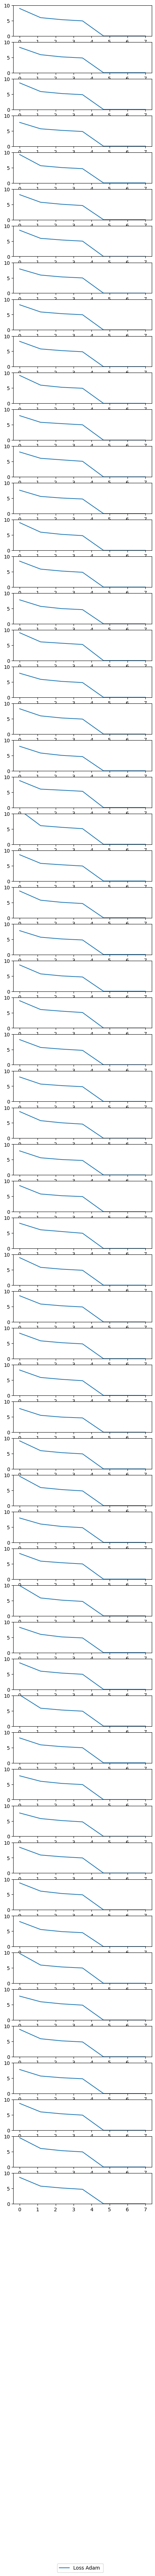

In [ ]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(5,80))

# fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(15,5))

for i in range(n_models):
  axes[i].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  axes[i].set_ylim([0,1e1])

  print("\\\\")

cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]


fig.legend(['Loss Adam '], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

## Predict and Evaluate Inverse Problem

In [ ]:
def lambdas(hists, iter_model, iter_init):
  return lambd_Adam1[i][0].transpose().iloc[-1,:].values[0]

df = pd.DataFrame(columns=['Adam'])
df = df.round(10)

for i in range(n_models):
  x = []
  for j in range(len(initial_lambdas)):
    x.append(lambdas(hists_Adam1, i, j))

  df.loc['Attempt '+str(i+1)] = x

print("Lambda Prediction Given U(x,t)")
df

Lambda Prediction Given U(x,t)


,Adam
Attempt 1,0.467063
Attempt 2,0.482067
Attempt 3,0.475473
Attempt 4,0.455241
Attempt 5,0.479230
Attempt 6,0.478750
Attempt 7,0.481909
Attempt 8,0.478445
Attempt 9,0.441553
Attempt 10,0.463157


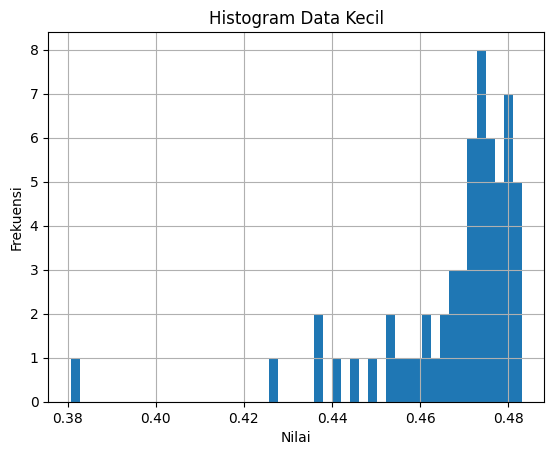

In [ ]:
# bins = np.linspace(0, max(df.Adam), 50)  # 20 bins antara 0 dan 0.0001
ax = df.iloc[:, 0].plot(kind='hist', bins=50, align='mid')

# plt.xticks(np.linspace(0, 0.00008, 11))  # Misal xtick tiap 0.00001
plt.xlabel("Nilai")
plt.ylabel("Frekuensi")
plt.title("Histogram Data Kecil")
plt.grid(True)
plt.show()

beta         KS=0.0965, p=0.5967, params=(np.float64(36.008391854130856), np.float64(0.9519689537611009), np.float64(-0.11344655012762994), np.float64(0.5964483485189722))
burr         KS=0.1220, p=0.3083, params=(np.float64(1537171075.0558686), np.float64(0.2323118009864899), np.float64(-4635114.2090328215), np.float64(4635114.688831247))
fisk         KS=0.1555, p=0.09862, params=(np.float64(377138618.792733), np.float64(-2762548.088533491), np.float64(2762548.559138799))
gengamma     KS=0.1772, p=0.04053, params=(np.float64(1.7838408116274742), np.float64(5093740.998141071), np.float64(-78572.34418442391), np.float64(78572.80757224579))
norm         KS=0.2100, p=0.008431, params=(np.float64(0.46760348280270897), np.float64(0.01680509974241412))
lognorm      KS=0.2100, p=0.008431, params=(np.float64(4.102743933772581e-06), -4095.6192943751757, np.float64(4096.086897823505))
invgauss     KS=0.2316, p=0.002593, params=(np.float64(0.004790885402574677), np.float64(0.17964937594525487), n

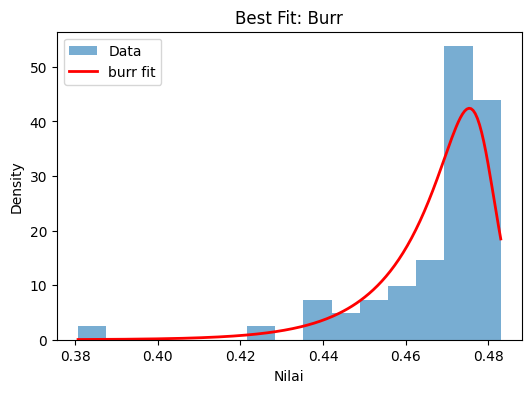

Mean Burr: 0.46780881844460964


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# If df is a DataFrame, pick the column you want to fit:
data = df.iloc[:, 0].to_numpy()  # 1D array

distributions = [
    stats.norm,          # Normal
    stats.expon,         # Exponential
    stats.gamma,         # Gamma
    stats.beta,          # Beta
    stats.lognorm,       # Lognormal
    stats.uniform,       # Uniform
    stats.invgauss,      # Inverse Gaussian
    stats.burr,          # Burr
    stats.fisk,          # Fisk (log-logistic)
    stats.gengamma       # Generalized Gamma
]

results = {}

# Fit tiap distribusi dan uji KS
for dist in distributions:
    try:
        params = dist.fit(data)
        ks_stat, ks_pval = stats.kstest(data, dist.cdf, args=params)
        results[dist.name] = {
            "KS_stat": float(ks_stat),
            "p_value": float(ks_pval),
            "params": params
        }
    except Exception as e:
        results[dist.name] = {"KS_stat": np.inf, "p_value": 0, "params": None}
        print(f"Gagal fit {dist.name}: {e}")

# Urutkan dari KS terkecil
sorted_results = sorted(results.items(), key=lambda x: x[1]["KS_stat"])

# Tampilkan hasil
for name, res in sorted_results:
    if res["params"] is not None:
        print(f"{name:12s} KS={res['KS_stat']:.4f}, p={res['p_value']:.4g}, params={res['params']}")

# Plot best fit
best_name, best_info = sorted_results[1]
best_dist = getattr(stats, best_name)
params = best_info["params"]

x = np.linspace(min(data), max(data), 200)
pdf = best_dist.pdf(x, *params)

plt.figure(figsize=(6,4))
plt.hist(data, bins=15, density=True, alpha=0.6, label="Data")
plt.plot(x, pdf, 'r-', lw=2, label=f"{best_name} fit")
plt.title(f"Best Fit: {best_name.capitalize()}")
plt.xlabel("Nilai")
plt.ylabel("Density")
plt.legend()
plt.show()

params = stats.burr.fit(data)
c, d, loc, scale = params
mean_burr = stats.burr.mean(c, d, loc=loc, scale=scale)
print("Mean Burr:", mean_burr)

In [ ]:
print(df.mean(axis=0).round(10))
df.loc['Average'] = df.mean(axis=0)
df.loc['StdDev'] = df.std(axis=0, ddof=1)
df.loc['CV'] = df.loc['StdDev'] / df.loc['Average']
df.loc[['Average', 'StdDev', 'CV']] = df.loc[['Average', 'StdDev', 'CV']].round(10)
print(df.tail(3))

Adam    0.467603
dtype: float64
             Adam
Average  0.467603
StdDev   0.016805
CV       0.035939


# Pelatihan Kasus Forward

In [ ]:
n_models = 2

arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'tanh', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i+2)
  models[i] = PINN_NeuralNet(lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_8', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_9', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

Text(0.5, 1, 'Combined Learning Rate')

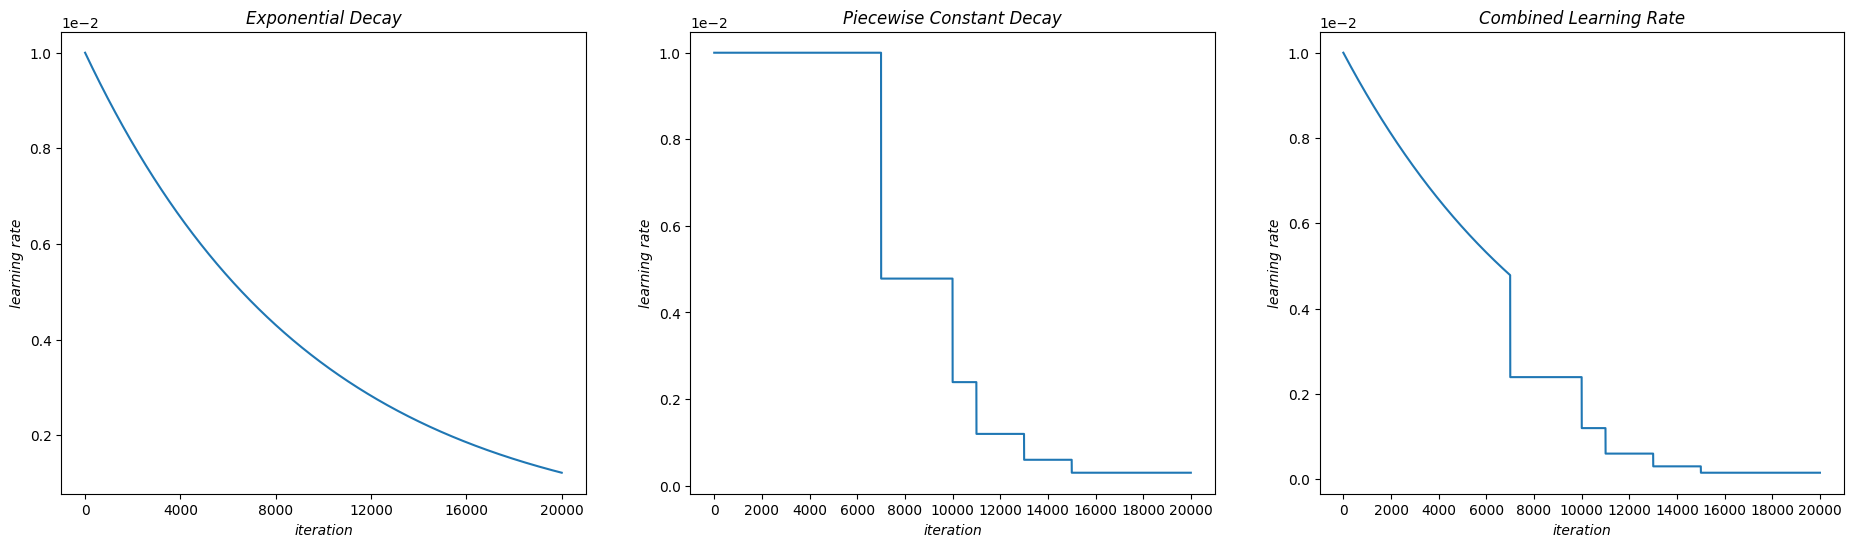

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 20000  # Extended range

fig = plt.figure(figsize=(23, 6))

# ExponentialDecay
initial_learning_rate = lr_comb.initial_learning_rate
decay_steps = lr_comb.decay_steps
decay_rate = lr_comb.decay_rate

learning_rate = []
for i in range(N+1):
    lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    learning_rate.append(lr)

plt.subplot(1, 3, 1)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 4000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Exponential Decay', y=1, fontstyle='italic')

# Piecewise Constant Decay
boundaries = lr_comb.boundaries
values = lr_comb.values

learning_rate = []
for i in range(N+1):
    for j in range(len(boundaries)):
        if i <= boundaries[0]:
            lr = lr_comb.initial_learning_rate
        elif i <= boundaries[j]:
            lr = values[j-1]
            break
        else:
            lr = values[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 2)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Piecewise Constant Decay', y=1, fontstyle='italic')

# Extended Combined Decay
boundaries = lr_comb.boundaries
values_steps = lr_comb.values_steps  # should be a list like [2, 2, 2, ...]
if isinstance(values_steps, int):
    values_steps = [values_steps] * (len(boundaries))  # Make uniform if scalar

i_stop = boundaries[0]
learning_rate = []

learning_rate = []
i_stop = boundaries[0]

for i in range(N+1):
    if i <= i_stop:
        lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    else:
        for j in range(1, len(boundaries)):
            if boundaries[j-1] < i <= boundaries[j]:
                if i == boundaries[j-1] + 1:
                    # first step into this boundary: decay from previous segment
                    prev_lr = learning_rate[-1]
                    lr = prev_lr / values_steps[j-1]
                else:
                    lr = learning_rate[-1]  # maintain constant
                break
        else:
            # After the last boundary
            lr = learning_rate[-1] / values_steps[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 3)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0,0))
plt.title('Combined Learning Rate', y=1, fontstyle='italic')



In [16]:
pred_lambda = [0.46780881844460964]
# pred_lambda = [3.6534748e-05]

In [ ]:
timeout = 1200
start_from = 1


models_Adam_comb = [None]*n_models
hists_Adam_comb = [None]*n_models
batch_size = 4096

for i in range(start_from - 1, n_models):
    models_Adam_comb[i] = []
    hists_Adam_comb[i] = []
    for j, lambd_val in enumerate(pred_lambda):
        print('{:s}\nModel Iteration: {:d}, Lambda Iteration: {:d}\n{:s}'.format(
            50*'-', i+1, j+1, 50*'-'))

        tf.random.set_seed(i + j+2)  # Use a combined seed for reproducibility

        # Build and initialize model
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))

        # Set weights and lambda from base model
        models_Adam_comb[i][j].set_weights(models[i].get_weights())
        # Prepare optimizer
        optim_Adam_comb = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay =1e-3)

        # Initialize solver
        solver = PINN_PDESolver(models_Adam_comb[i][j], X_train, fun_r_fwd, get_r_fwd,lambd_val)

        # Train the model
        print('\n\nAdam - Combined Learning Rate\n')
        solver.solve_with_TFoptimizer(optim_Adam_comb, X_train, u_train, W_u, W_v,timeout=timeout,batch_size=batch_size)

        # Store training history
        hists_Adam_comb[i].append(solver.hist)

        print('\n\n\n')

In [18]:
path = dir + "NO2Model/Fourier/Local_Fourier_fwd_tanh/"

In [ ]:
for i in range(n_models):
  for j in range(len(pred_lambda)):
    models_Adam_comb[i][j].save_weights(path+"_"+str(i)+"_model_Adam_comb_"+str(j)+".weights.h5", 'h5')


for i in range(n_models):
  for j in range(len(pred_lambda)):
    np.savetxt(path + "loss/hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv", hists_Adam_comb[i][j], delimiter=",")

In [19]:
n_models = 5

arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'tanh', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = PINN_NeuralNet(lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

models_Adam_comb = [None]*n_models # Initialize models_Adam_comb with the correct size

for i in range(0, n_models):
    models_Adam_comb[i] = []
    for j in range(len(pred_lambda)):
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))
        _ = models_Adam_comb[i][j](tf.zeros((1, 3)))
        models_Adam_comb[i][j].load_weights(
            path + "_" + str(i) + "_model_Adam_comb_" + str(j) + ".weights.h5"
        )


hists_Adam_comb = [None] * n_models

for i in range(0,n_models):
    hists_Adam_comb[i] = []
    for j in range(len(pred_lambda)):
        hists_Adam_comb[i].append(pd.read_csv(path + "/loss/hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv",header=None))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_2', however 

## Grafik Loss

len Atempt-0 Lambda ke- 0:  15
\\
len Atempt-1 Lambda ke- 0:  15
\\
len Atempt-2 Lambda ke- 0:  15
\\
len Atempt-3 Lambda ke- 0:  14
\\
len Atempt-4 Lambda ke- 0:  15
\\


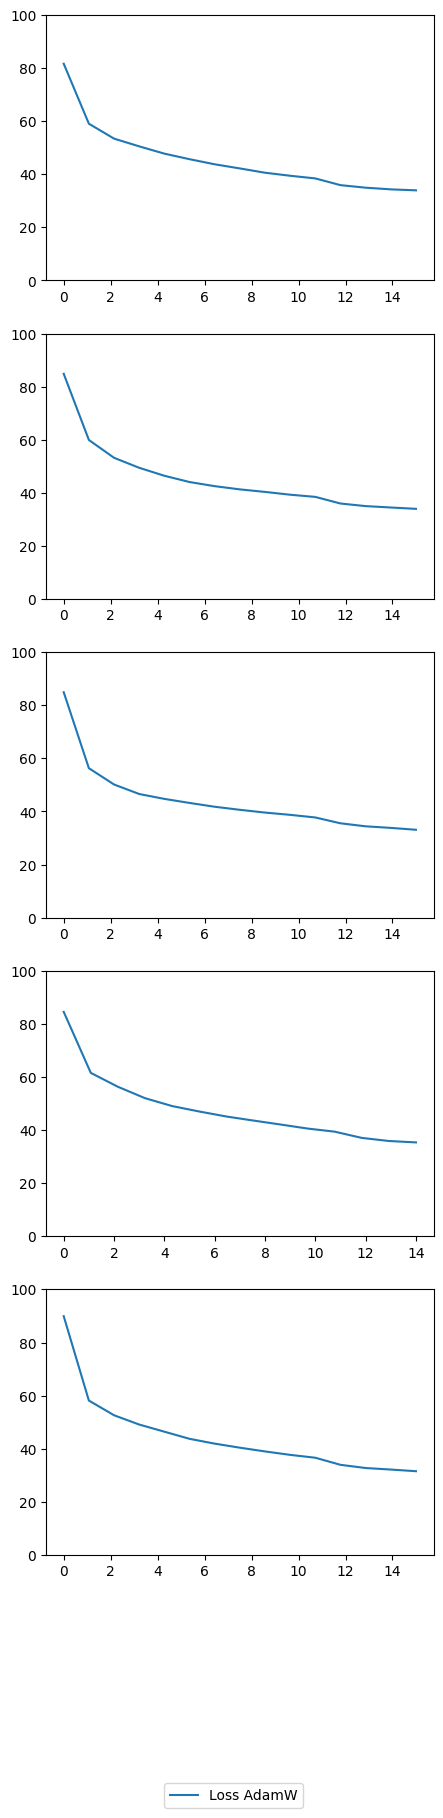

In [ ]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(pred_lambda), figsize=(5,20))

for i in range(n_models):
  for j in range(len(pred_lambda)):
    axes[i].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
    axes[i].set_ylim([0,100])
  # for j in range(len(pred_lambda)):
  #   axes[j].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
  #   axes[j].set_ylim([0,5e4])


    print(f"len Atempt-{i} Lambda ke- {j}: ",len(hists_Adam_comb[i][j]))
  print("\\\\")

  rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

fig.legend(['Loss AdamW'], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

### Prediction and Evaluation

In [ ]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())


In [ ]:
lb = tf.constant(lb, dtype=tf.float32)
ub = tf.constant(ub, dtype=tf.float32)

In [ ]:
train_Adam_comb = []


t_unique_train = np.sort(train_df['time'].unique())
x_unique_train = np.sort(train_df['x_coord'].unique())
y_unique_train = np.sort(train_df['y_coord'].unique())


for i in range(n_models):
  for j in range(len(pred_lambda)):
    train_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_train, t_unique_train, x_unique_train, y_unique_train))


df = pd.DataFrame(columns=['Adam'])
initial_lambdas = pred_lambda

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = train_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_train.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam
Attempt 1,"(1.3163694, 12.789294)"
Attempt 2,"(1.3166653, 12.882047)"
Attempt 3,"(1.2944595, 12.499441)"
Attempt 4,"(1.348284, 13.225874)"
Attempt 5,"(1.280521, 12.494532)"


In [ ]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())

preds_Adam_comb = []

for i in range(n_models):
  for j in range(len(pred_lambda)):
    preds_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_test, t_unique, x_unique, y_unique))


In [ ]:
df = pd.DataFrame(columns=['Adam'])
initial_lambdas = pred_lambda

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = preds_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_test.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam
Attempt 1,"(1.3227801, 12.854401)"
Attempt 2,"(1.323003, 12.936771)"
Attempt 3,"(1.3002046, 12.550529)"
Attempt 4,"(1.3535092, 13.27579)"
Attempt 5,"(1.2858874, 12.546794)"


In [ ]:
def summarise_attempts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a tidy table with mean, sample‑SD and CV
    for both numbers contained in each tuple cell.
    """
    summaries = {}
    for col in df.columns:
        arr = np.vstack(df[col].to_numpy())     # shape = (n_attempts, 2)
        μ  = arr.mean(axis=0)                   # mean
        σ  = arr.std(axis=0, ddof=1)            # sample SD (ddof=1)
        cv = σ / μ                              # coefficient of variation
        summaries[col] = {
            "mean_MAE": μ[0], "sd_MAE": σ[0], "cv_MAE": cv[0],
            "mean_MAPE": μ[1], "sd_MAPE": σ[1], "cv_MAPE": cv[1],
        }
    return pd.DataFrame(summaries).T

stats_df = summarise_attempts(df)
print(stats_df)

      mean_MAE    sd_MAE    cv_MAE  mean_MAPE   sd_MAPE   cv_MAPE
Adam  1.317077  0.025751  0.019551  12.832857  0.303724  0.023668


In [ ]:
weights = models_Adam_comb[4][0].get_weights()

for i, w in enumerate(weights):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[-1.46158680e-01 -4.42792438e-02 -1.75830469e-01 -5.24970472e-01
   9.50511619e-02  4.19120848e-01  2.12726760e+00  1.09476066e+00
  -8.95811543e-02 -3.43705446e-01  4.16211039e-01 -1.97959006e-01
   5.25198817e-01  3.56094420e-01  6.32723391e-01  1.11326694e+00
  -3.07120800e-01  8.03648055e-01  5.48593223e-01  1.81505227e+00
   1.46317971e+00 -1.05977571e+00 -1.55399847e+00 -8.40206146e-01
   1.68878162e+00  1.66655460e-03  7.92235434e-01 -6.13783121e-01
  -1.82911637e-03 -6.22461081e-01  9.02803957e-01 -1.44735962e-01
  -7.92787850e-01 -6.13910481e-02  1.51428491e-01  1.40883982e+00
   3.70118059e-02  6.33420229e-01  6.67851985e-01  5.77514648e-01
  -2.08727539e-01  1.97660255e+00  2.44092822e+00 -5.72860658e-01
  -1.76985458e-01 -3.43510509e+00 -3.09040785e-01  1.89683390e+00
  -1.63033009e+00  8.39109898e-01 -7.23247528e-01 -1.51069379e+00
  -2.29891717e-01 -1.11489356e+00  7.30443120e-01 -2.10071230e+00
   3.61579269e-01  1.25755322e+00 -3.82578582e-01 

# Rekonstruksi atau Imputasi

## Imputasi

In [20]:
df = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/NO2_Land_Grid_Jabodetabek.csv")
df['date'] = pd.to_datetime(df['date'])
df=df.rename(columns={"mean":"NO2_mean","latitude":"y_coord","longitude":"x_coord"})
df['time'] = (df['date'] - df['date'].min()).dt.days
df.x_coord = df.x_coord*100
df.y_coord = df.y_coord*100

missing_rows = df[(df["NO2_mean"].isna()) | (df["NO2_mean"] < 0)][["time", "x_coord", "y_coord"]]
missing_rows

# --- Convert to numpy for model input ---
X_missing = missing_rows.to_numpy(dtype=np.float32)

# --- Predict using your model ---
y_pred = models_Adam_comb[4][0].predict_on_batch(X_missing).reshape(-1)
y_pred = y_pred*1e-5
df.x_coord = df.x_coord/100
df.y_coord = df.y_coord/100
df_imputation = df.copy()

# --- Fill missing values ---
df_imputation.loc[(df_imputation["NO2_mean"].isna()) | (df_imputation["NO2_mean"] < 0), "NO2_mean"] = y_pred

df_imputation.describe()

,date,NO2_mean,x_coord,y_coord,time
count,4370510,4.370510e+06,4.370510e+06,4.370510e+06,4.370510e+06
mean,2024-04-29 11:59:59.999999744,1.058163e-04,1.068073e+02,-6.373936e+00,3.645000e+02
min,2023-05-01 00:00:00,1.179439e-06,1.063433e+02,-6.782236e+00,0.000000e+00
25%,2023-10-30 00:00:00,7.251604e-05,1.065949e+02,-6.547693e+00,1.820000e+02
50%,2024-04-29 12:00:00,9.476213e-05,1.068072e+02,-6.362443e+00,3.645000e+02
75%,2024-10-29 00:00:00,1.272904e-04,1.070195e+02,-6.201893e+00,5.470000e+02
max,2025-04-29 00:00:00,7.509617e-04,1.072922e+02,-5.919887e+00,7.290000e+02
std,NaN,4.797426e-05,2.420086e-01,2.069754e-01,2.107327e+02


In [21]:
df_imputation

,date,NO2_mean,x_coord,y_coord,time
0,2023-05-01,0.000124,106.347149,-6.084704,0
1,2023-05-01,0.000106,106.344359,-6.076563,0
2,2023-05-01,0.000106,106.343339,-6.067594,0
3,2023-05-01,0.000127,106.353334,-6.110698,0
4,2023-05-01,0.000106,106.352747,-6.103510,0
...,...,...,...,...,...
4370505,2025-04-29,0.000059,107.288256,-6.142861,729
4370506,2025-04-29,0.000079,107.292069,-6.211870,729
4370507,2025-04-29,0.000074,107.292225,-6.204918,729
4370508,2025-04-29,0.000061,107.291380,-6.191702,729


t = 522


/tmp/ipython-input-1152078068.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  jawa['centroid'] = jawa.geometry.centroid
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipython-input-1152078068.py:46: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")
/tmp/ipython-in

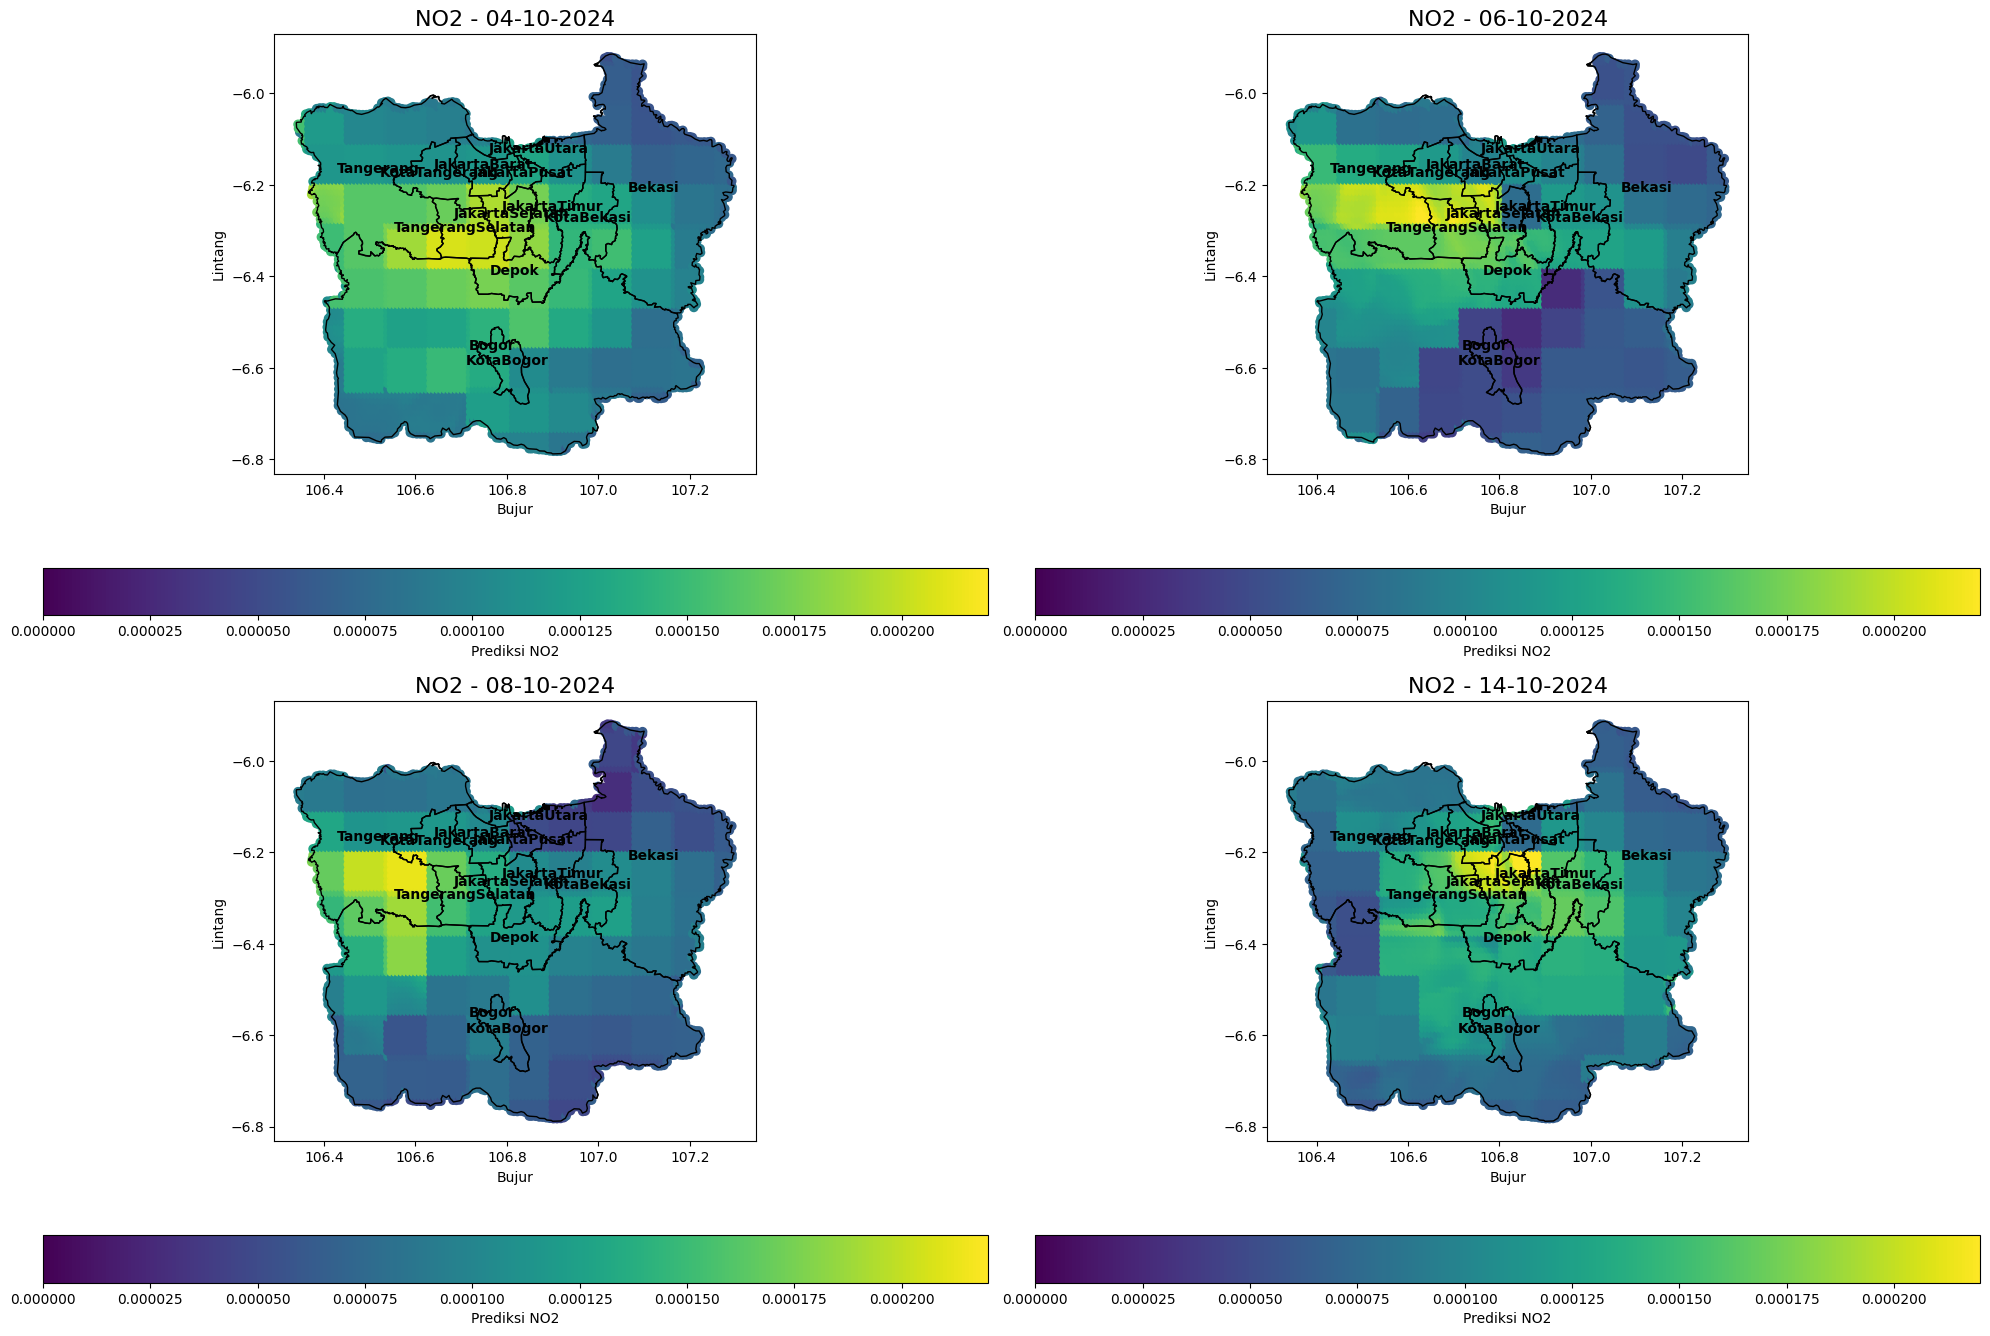

In [22]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd

# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
target_day = 4
target_month = 10
target_year = 2024
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)
indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

jawa_provinces = ['Tangerang', 'Bogor', 'KotaTangerang', 'JakartaBarat',
       'JakartaUtara', 'JakartaSelatan', 'KotaBogor',
       'Depok', 'JakartaPusat', 'JakartaTimur', 'Bekasi',
       'KotaBekasi','TangerangSelatan']
jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]
jawa['centroid'] = jawa.geometry.centroid


fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten()

# Loop through t, t+1, t+2, t+3
for i, day_offset in enumerate([0,2,4,10]):
    time_to_visualize = t + day_offset

    df_visualize = df_imputation[df_imputation['time'] == time_to_visualize].copy()
    ax = axes[i]

    if df_visualize.empty:
        ax.set_title(f"No data for t+{day_offset} ({(target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')})")
        ax.axis('off')
        continue

    geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
    gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)

    merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

    jawa.plot(ax=ax, color='lightgray', edgecolor='black')
    jawa.boundary.plot(ax=ax, color='black', linewidth=1)

    if not merged_gdf.empty:
        merged_gdf.plot(column='NO2_mean', ax=ax, legend=True, vmin = 0 , vmax = 2.2e-4,cmap='viridis', legend_kwds={'label': "Prediksi NO2", 'orientation': "horizontal"})

    # Add city names
    for idx, row in jawa.iterrows():
        ax.annotate(
            text=row['NAME_2'],
            xy=(row['centroid'].x, row['centroid'].y),
            ha='center', fontsize=10, color='black', weight='bold'
        )

    # Titles & limits
    ax.set_title(f"NO2 - {(target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')}", fontsize=16)
    ax.set_xlabel("Bujur")
    ax.set_ylabel("Lintang")

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

t = 522


/tmp/ipython-input-4219933133.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  jawa['centroid'] = jawa.geometry.centroid
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipython-input-4219933133.py:46: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")
/tmp/ipython-in

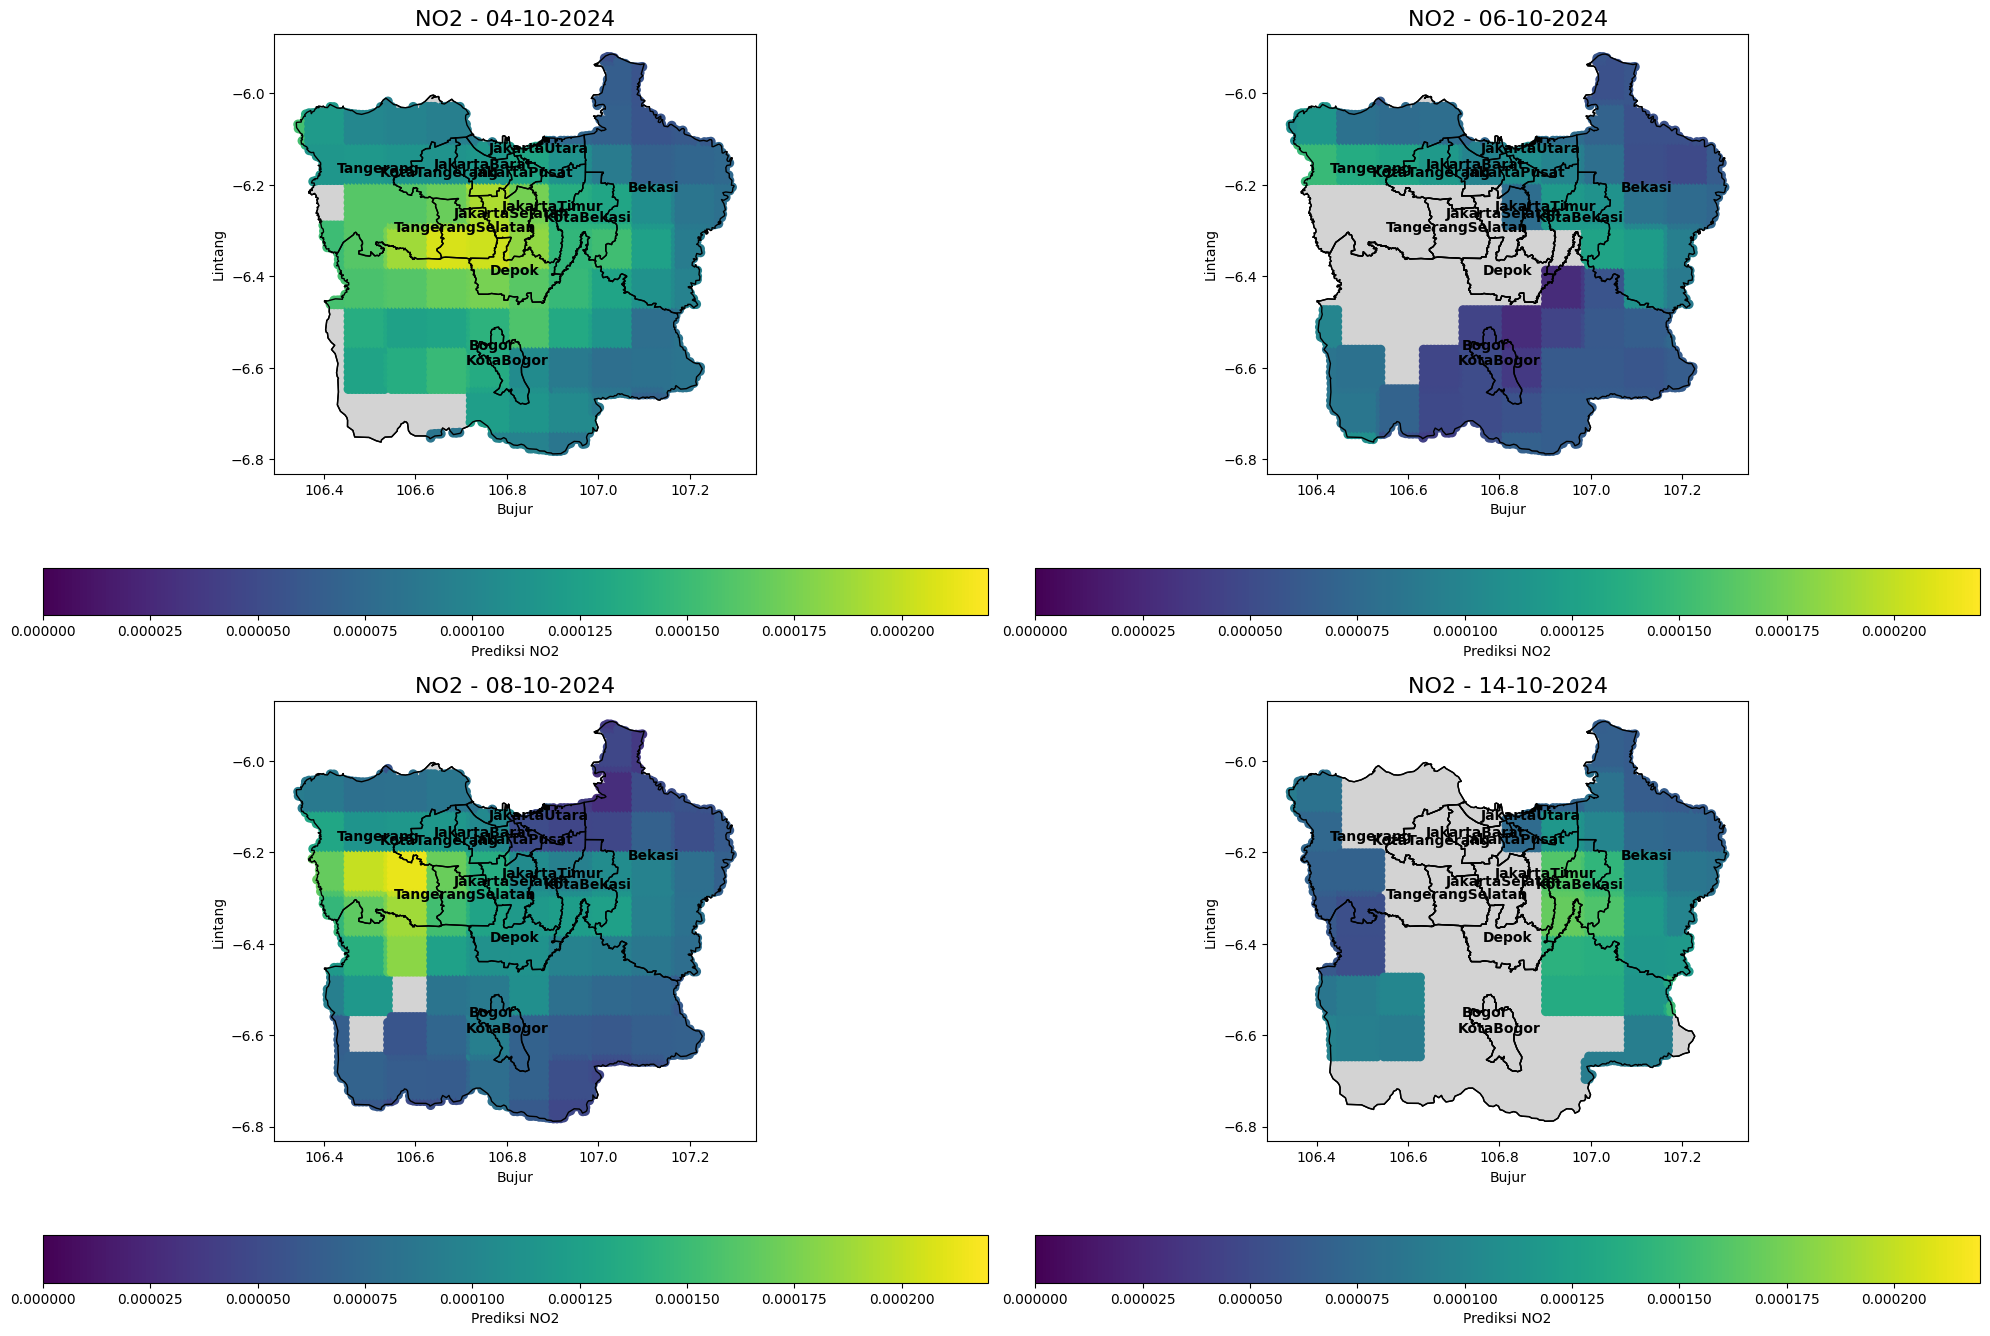

In [23]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd

# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
target_day = 4
target_month = 10
target_year = 2024
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)
indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

jawa_provinces = ['Tangerang', 'Bogor', 'KotaTangerang', 'JakartaBarat',
       'JakartaUtara', 'JakartaSelatan', 'KotaBogor',
       'Depok', 'JakartaPusat', 'JakartaTimur', 'Bekasi',
       'KotaBekasi','TangerangSelatan']
jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]
jawa['centroid'] = jawa.geometry.centroid


fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten()

# Loop through t, t+1, t+2, t+3
for i, day_offset in enumerate([0,2,4,10]):
    time_to_visualize = t + day_offset

    df_visualize = df[df['time'] == time_to_visualize].copy()
    ax = axes[i]

    if df_visualize.empty:
        ax.set_title(f"No data for t+{day_offset} ({(target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')})")
        ax.axis('off')
        continue

    geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
    gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)

    merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

    jawa.plot(ax=ax, color='lightgray', edgecolor='black')
    jawa.boundary.plot(ax=ax, color='black', linewidth=1)

    if not merged_gdf.empty:
        merged_gdf.plot(column='NO2_mean', ax=ax, vmin = 0 , vmax = 2.2e-4, legend=True, cmap='viridis', legend_kwds={'label': "Prediksi NO2", 'orientation': "horizontal"})

    # Add city names
    for idx, row in jawa.iterrows():
        ax.annotate(
            text=row['NAME_2'],
            xy=(row['centroid'].x, row['centroid'].y),
            ha='center', fontsize=10, color='black', weight='bold'
        )

    # Titles & limits
    ax.set_title(f"NO2 - {(target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')}", fontsize=16)
    ax.set_xlabel("Bujur")
    ax.set_ylabel("Lintang")

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

## Rekonstruksi

In [ ]:
import numpy as np
import pandas as pd
import math
import os
from google.colab import files
from concurrent.futures import ThreadPoolExecutor

# --- 1. Load data dan siapkan grid (1e-4 spacing) ---

# Misal Anda sudah memiliki filtered_df
# Jika belum, upload:
# uploaded = files.upload()
# filtered_df = pd.read_csv("filtered_df.csv")

step = 0.5  # Resolusi

t_min, t_max = filtered_df["time"].min(), filtered_df["time"].max()
x_min, x_max = filtered_df["x_coord"].min(), filtered_df["x_coord"].max()
y_min, y_max = filtered_df["y_coord"].min(), filtered_df["y_coord"].max()

t_points = np.arange(t_min, t_max + step, 1, dtype=np.float32)
x_points = np.arange(x_min, x_max + step, step, dtype=np.float32)
y_points = np.arange(y_min, y_max + step, step, dtype=np.float32)


# --- 2. Pilih model dan path hasil ---
target_indices = [(4, 0)]  # sesuaikan
models_to_use  = [models_Adam_comb[i][j] for i, j in target_indices]
model_labels   = [f"m{i}_{j}" for i, j in target_indices]
file_paths     = [f"/content/NO2_Local_M3_tanh_prediction_{label}.csv" for label in model_labels]

# --- 3. Buat file output kosong dengan header ---
for path in file_paths:
    if os.path.exists(path):
        os.remove(path)
    with open(path, "w") as f:
        f.write("t,x,y,prediction\n")

# --- 4. Precompute spatial meshgrid (xy pairs) sekali saja ---
xy_pairs = np.stack(np.meshgrid(x_points, y_points, indexing="ij"), -1).reshape(-1, 2)

# --- 5. Fungsi batch generator ---
def gen_batches(t_vec, batch_size=1_000_000):
    for t in t_vec:
        t_col = np.full((xy_pairs.shape[0], 1), t, dtype=np.float32)
        tx_y = np.hstack([t_col, xy_pairs])
        n_rows = tx_y.shape[0]
        n_batch = math.ceil(n_rows / batch_size)
        for k in range(n_batch):
            yield t, tx_y[k * batch_size : (k + 1) * batch_size]

# --- 6. Fungsi prediksi + tulis ke file ---
def predict_and_write(model, batch, path):
    pred = model.predict_on_batch(batch).reshape(-1, 1)
    output = np.hstack([batch, pred])
    df = pd.DataFrame(output, columns=["t", "x", "y", "prediction"])
    df.to_csv(path, mode="a", header=False, index=False, float_format="%.6g")

# --- 7. Loop utama: batch per waktu + paralel tulis model ---
for t_val, batch in gen_batches(t_points):
    print(f"Processing time: {t_val}, Batch shape: {batch.shape}")
    with ThreadPoolExecutor() as executor:
        for model, path in zip(models_to_use, file_paths):
            executor.submit(predict_and_write, model, batch, path)

Processing time: 0.0, Batch shape: (32470, 3)
Processing time: 1.0, Batch shape: (32470, 3)
Processing time: 2.0, Batch shape: (32470, 3)
Processing time: 3.0, Batch shape: (32470, 3)
Processing time: 4.0, Batch shape: (32470, 3)
Processing time: 5.0, Batch shape: (32470, 3)
Processing time: 6.0, Batch shape: (32470, 3)
Processing time: 7.0, Batch shape: (32470, 3)
Processing time: 8.0, Batch shape: (32470, 3)
Processing time: 9.0, Batch shape: (32470, 3)
Processing time: 10.0, Batch shape: (32470, 3)
Processing time: 11.0, Batch shape: (32470, 3)
Processing time: 12.0, Batch shape: (32470, 3)
Processing time: 13.0, Batch shape: (32470, 3)
Processing time: 14.0, Batch shape: (32470, 3)
Processing time: 15.0, Batch shape: (32470, 3)
Processing time: 16.0, Batch shape: (32470, 3)
Processing time: 17.0, Batch shape: (32470, 3)
Processing time: 18.0, Batch shape: (32470, 3)
Processing time: 19.0, Batch shape: (32470, 3)
Processing time: 20.0, Batch shape: (32470, 3)
Processing time: 21.0, 

In [24]:
prediction_df =pd.read_csv(dir+"Reconstruction/NO2_Local/NO2_Local_M3_tanh_prediction_m4_0.csv")

prediction_cleaned_df =prediction_df.copy()
prediction_cleaned_df['prediction'] = prediction_df['prediction'].apply(lambda x: 0 if x < 0 else x)
prediction_df['prediction']= prediction_df['prediction']*1e-5
prediction_df['x'] = prediction_df['x']/100
prediction_df['y'] = prediction_df['y']/100

In [25]:
prediction_df[prediction_df.prediction<0]

,t,x,y,prediction
22695850,698,107.278,-6.78224,-2.369290e-07
22696020,698,107.283,-6.78224,-1.856890e-06
22696190,698,107.288,-6.78224,-2.826310e-06
22696360,698,107.293,-6.78224,-3.721240e-06
22727980,699,107.268,-6.78224,-8.822980e-09
...,...,...,...,...
23702945,729,107.293,-6.70724,-5.240290e-05
23702946,729,107.293,-6.70224,-3.934680e-05
23702947,729,107.293,-6.69724,-4.742170e-05
23702948,729,107.293,-6.69224,-4.946190e-05


In [26]:
prediction_df

,t,x,y,prediction
0,0,106.343,-6.78224,0.000071
1,0,106.343,-6.77724,0.000072
2,0,106.343,-6.77224,0.000075
3,0,106.343,-6.76724,0.000077
4,0,106.343,-6.76224,0.000079
...,...,...,...,...
23703095,729,107.293,-5.95724,0.000098
23703096,729,107.293,-5.95224,0.000103
23703097,729,107.293,-5.94724,0.000110
23703098,729,107.293,-5.94224,0.000118


/tmp/ipython-input-3974585854.py:24: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  jawa['centroid'] = jawa.geometry.centroid
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipython-input-3974585854.py:47: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")
/tmp/ipython-in

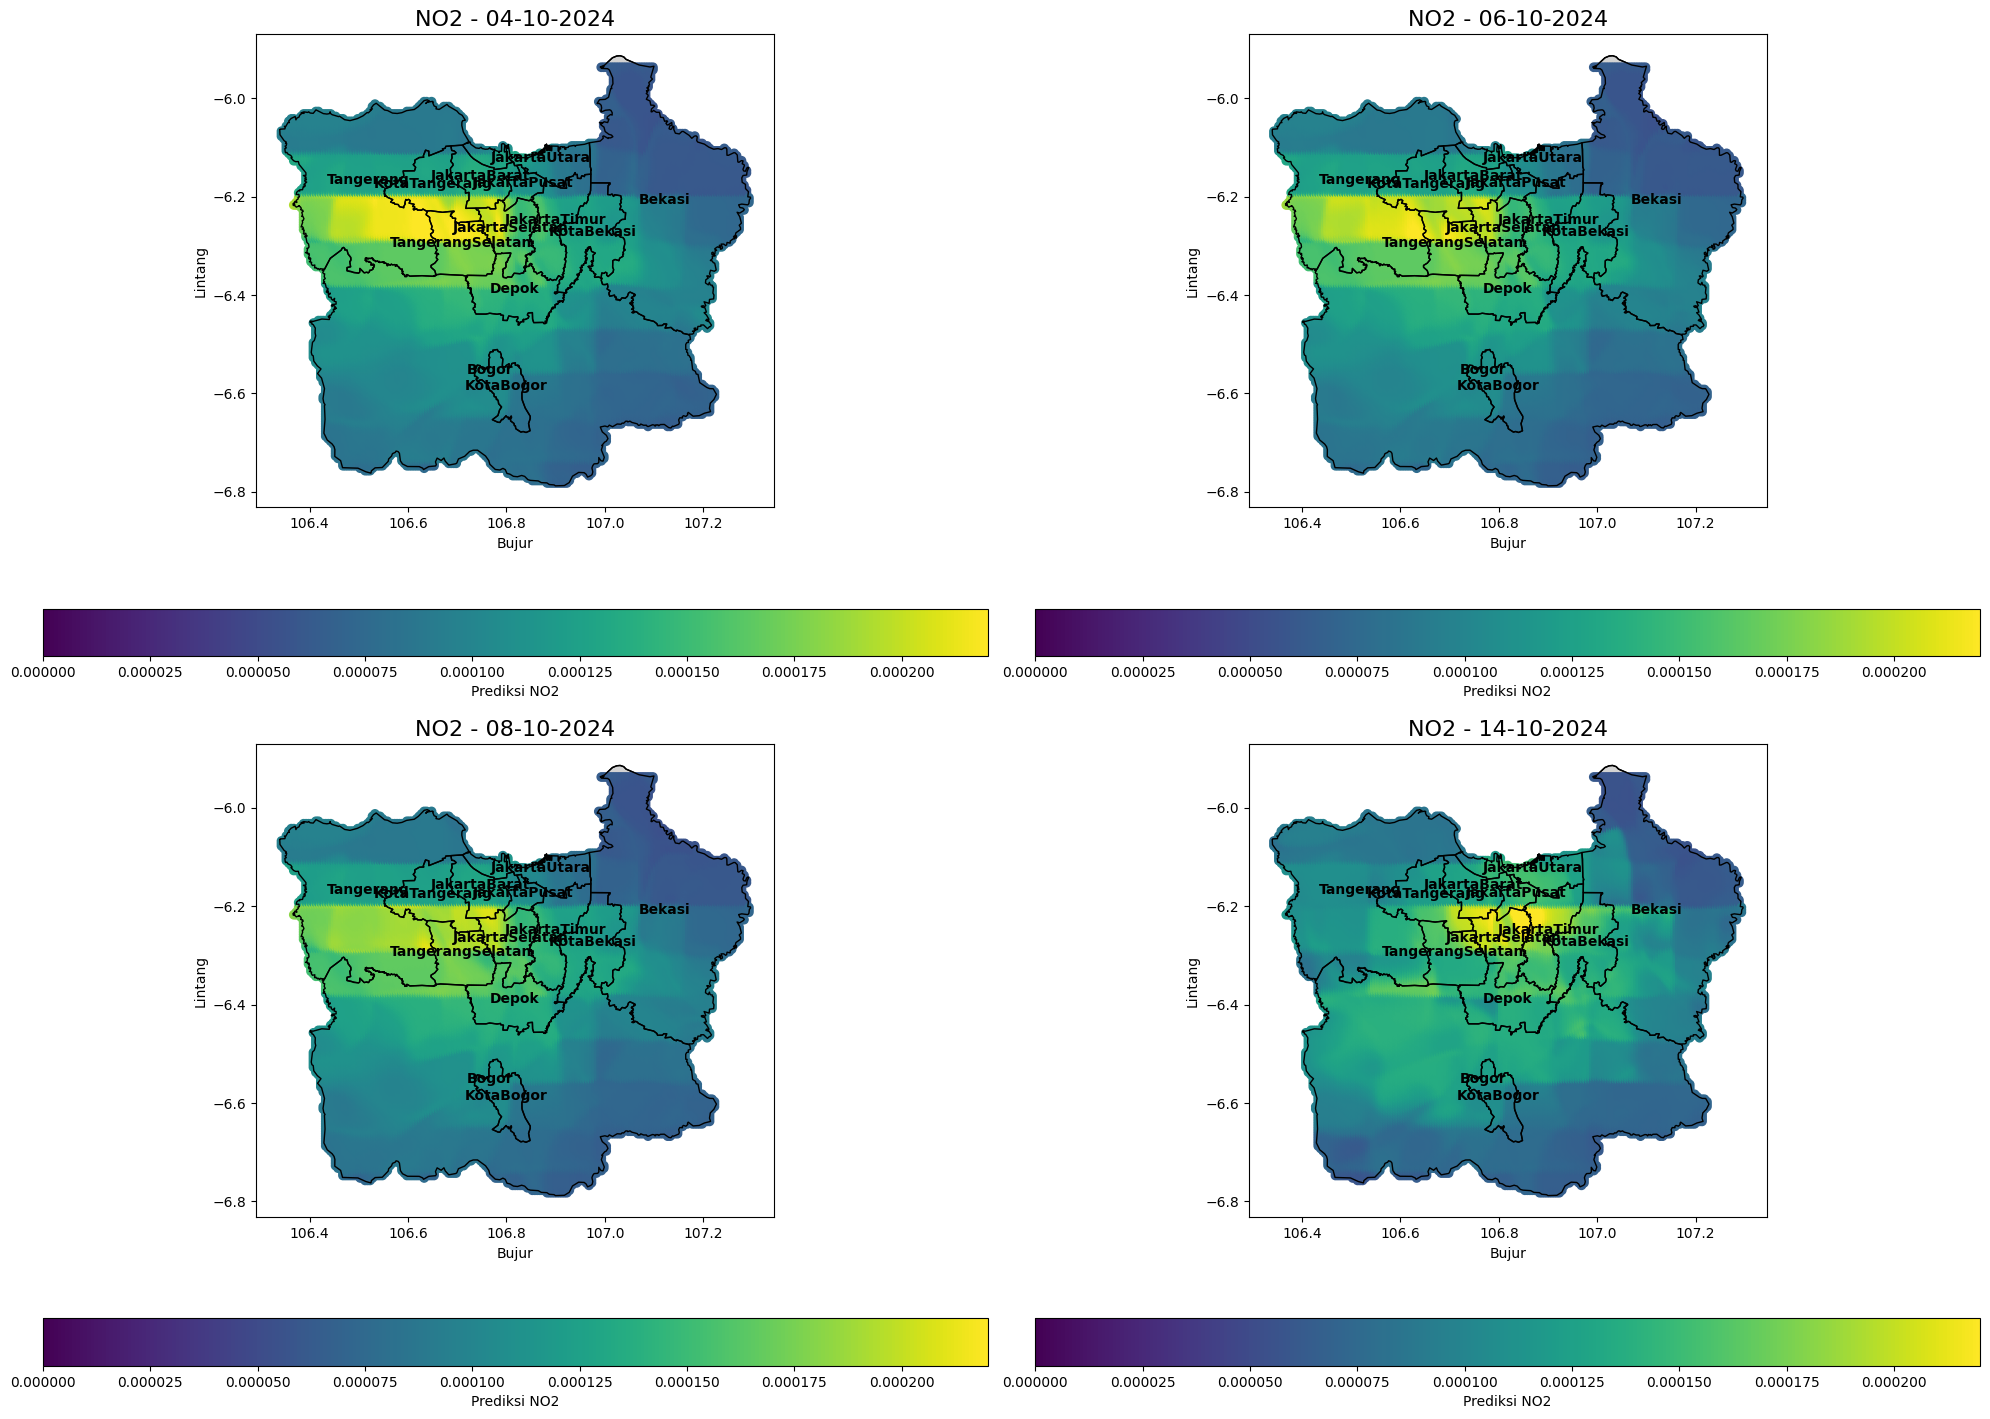

In [27]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd

# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
target_day = 4
target_month = 10
target_year = 2024
target_date = datetime(target_year, target_month, target_day)

# --- Step 3: Prepare geographical data (Bangkok) ---
indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

jawa_provinces = ['Tangerang', 'Bogor', 'KotaTangerang', 'JakartaBarat',
       'JakartaUtara', 'JakartaSelatan', 'KotaBogor',
       'Depok', 'JakartaPusat', 'JakartaTimur', 'Bekasi',
       'KotaBekasi','TangerangSelatan']
jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]
jawa['centroid'] = jawa.geometry.centroid

# --- Step 4: Create 4 consecutive days ---
dates = [target_date + timedelta(days=i) for i in range(4)]

# --- Step 5: Plot in 2×2 frame ---
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, day_offset in enumerate([0,2,4,10]):
    time_to_visualize = t + day_offset

    df_visualize = prediction_df[prediction_df['t'] == time_to_visualize].copy()
    ax = axes[i]

    if df_visualize.empty:
        ax.set_title(f"No data for t+{day_offset} ({(target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')})")
        ax.axis('off')
        continue

    geometry = [Point(xy) for xy in zip(df_visualize['x'], df_visualize['y'])]
    gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)

    merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

    jawa.plot(ax=ax, color='lightgray', edgecolor='black')
    jawa.boundary.plot(ax=ax, color='black', linewidth=1)

    if not merged_gdf.empty:
        merged_gdf.plot(column='prediction', ax=ax, legend=True, vmin = 0 , vmax = 2.2e-4,cmap='viridis', legend_kwds={'label': "Prediksi NO2", 'orientation': "horizontal"})

    # Add city names
    for idx, row in jawa.iterrows():
        ax.annotate(
            text=row['NAME_2'],
            xy=(row['centroid'].x, row['centroid'].y),
            ha='center', fontsize=10, color='black', weight='bold'
        )

    # Titles & limits
    ax.set_title(f"NO2 - {(target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')}", fontsize=16)
    ax.set_xlabel("Bujur")
    ax.set_ylabel("Lintang")

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

t = 522


/tmp/ipython-input-3404809594.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  jawa['centroid'] = jawa.geometry.centroid
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipython-input-3404809594.py:46: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")
/tmp/ipython-in

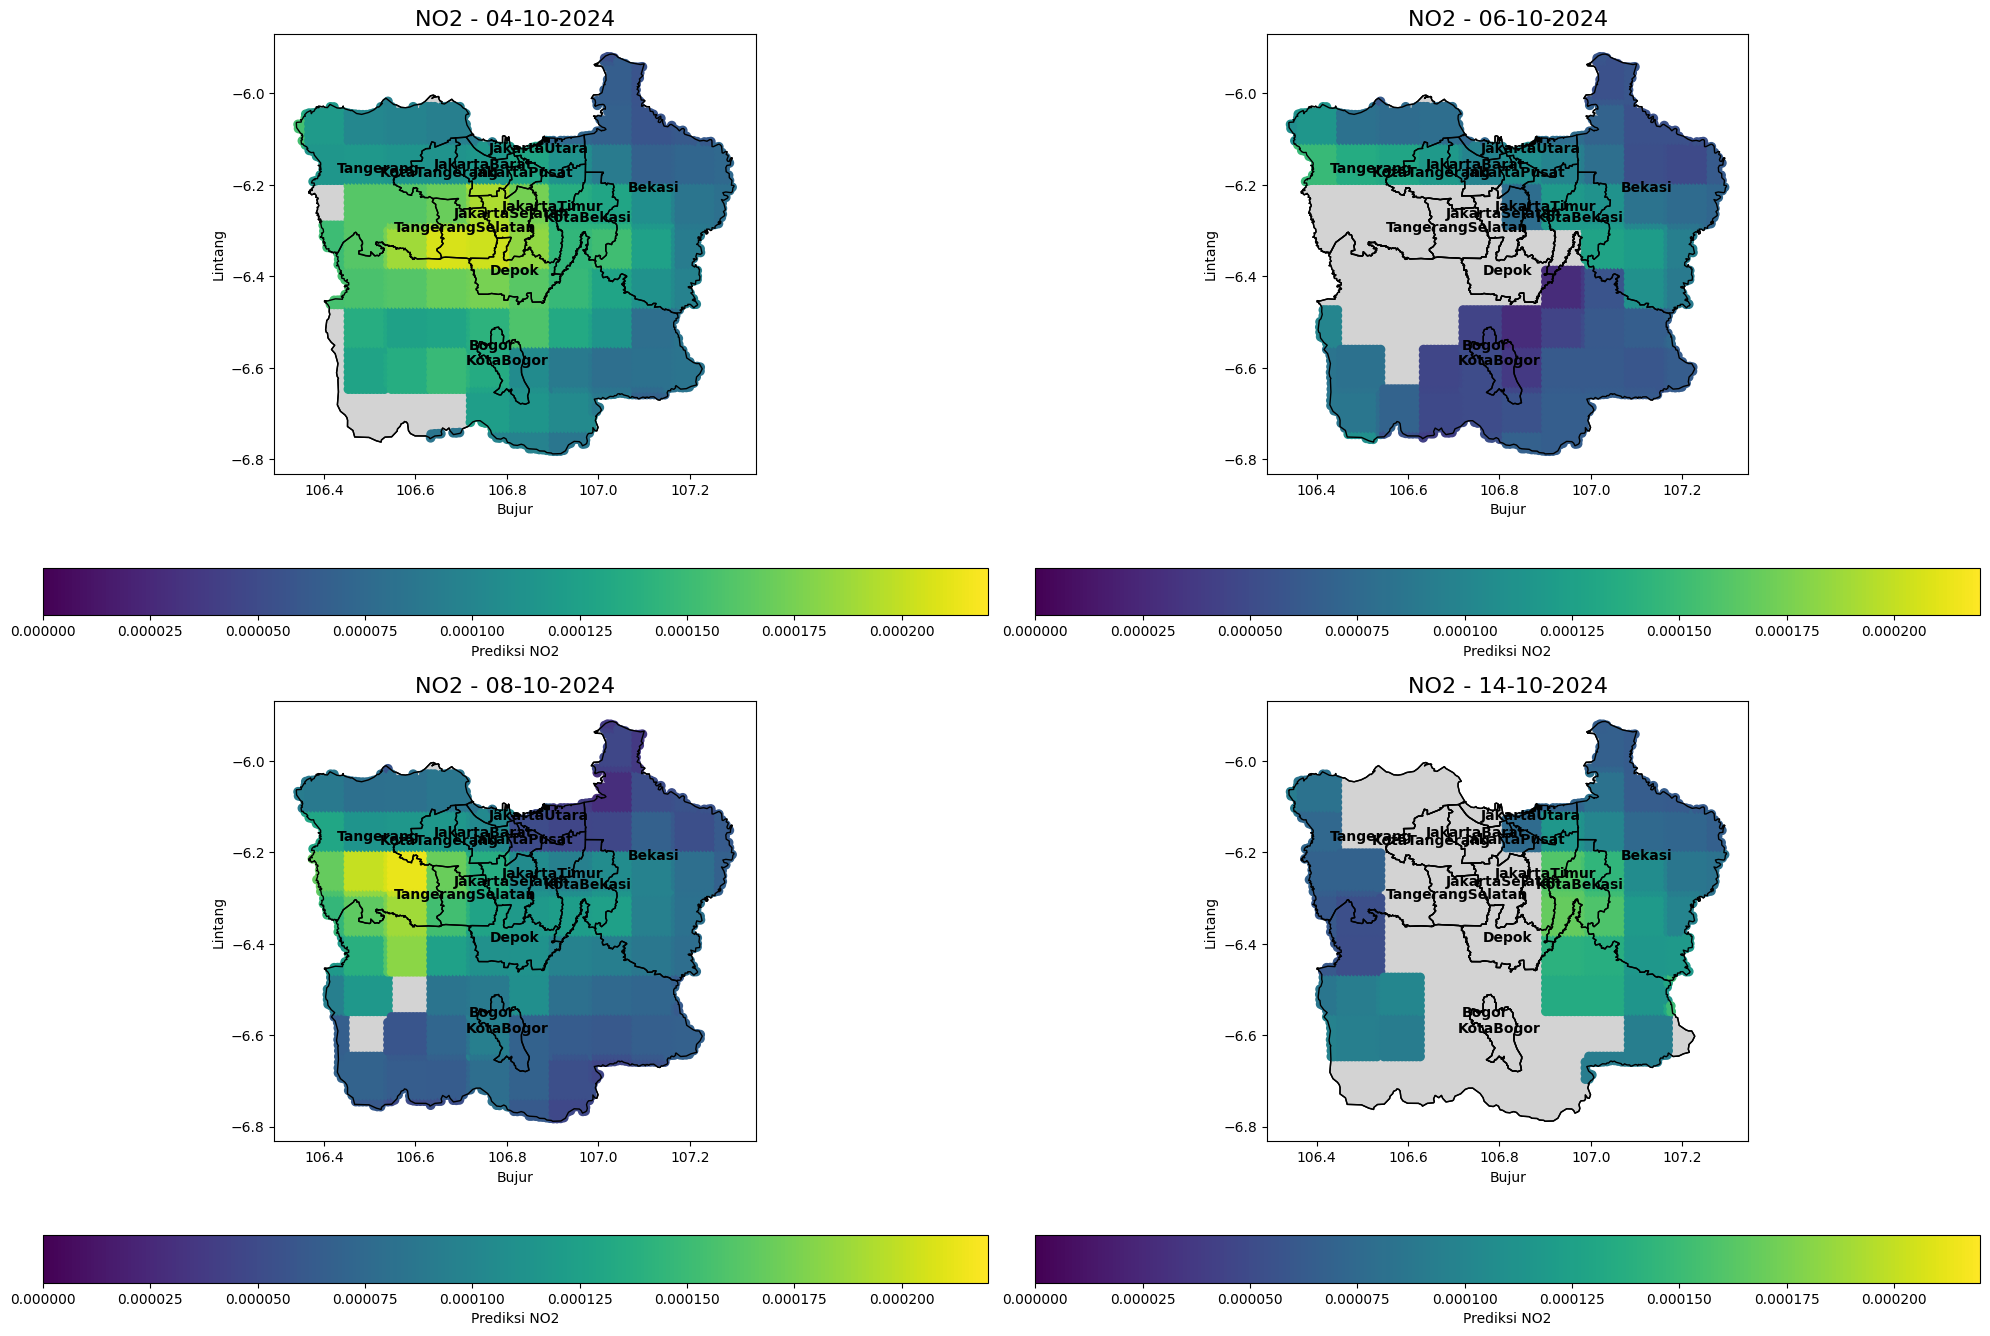

In [28]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd

# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
target_day = 4
target_month = 10
target_year = 2024
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)
indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

jawa_provinces = ['Tangerang', 'Bogor', 'KotaTangerang', 'JakartaBarat',
       'JakartaUtara', 'JakartaSelatan', 'KotaBogor',
       'Depok', 'JakartaPusat', 'JakartaTimur', 'Bekasi',
       'KotaBekasi','TangerangSelatan']
jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]
jawa['centroid'] = jawa.geometry.centroid


fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten()

# Loop through t, t+1, t+2, t+3
for i, day_offset in enumerate([0,2,4,10]):
    time_to_visualize = t + day_offset

    df_visualize = df[df['time'] == time_to_visualize].copy()
    ax = axes[i]

    if df_visualize.empty:
        ax.set_title(f"No data for t+{day_offset} ({(target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')})")
        ax.axis('off')
        continue

    geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
    gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)

    merged_gdf = gpd.sjoin(gdf, jawa, how="inner", predicate="within")

    jawa.plot(ax=ax, color='lightgray', edgecolor='black')
    jawa.boundary.plot(ax=ax, color='black', linewidth=1)

    if not merged_gdf.empty:
        merged_gdf.plot(column='NO2_mean', ax=ax, legend=True, cmap='viridis', vmin = 0 , vmax = 2.2e-4, legend_kwds={'label': "Prediksi NO2", 'orientation': "horizontal"})

    # Add city names
    for idx, row in jawa.iterrows():
        ax.annotate(
            text=row['NAME_2'],
            xy=(row['centroid'].x, row['centroid'].y),
            ha='center', fontsize=10, color='black', weight='bold'
        )

    # Titles & limits
    ax.set_title(f"NO2 - {(target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')}", fontsize=16)
    ax.set_xlabel("Bujur")
    ax.set_ylabel("Lintang")

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()